---
### **라이브러리 설치**
---

In [8]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from scipy.stats import mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


---
### **데이터 불러오기**
---

In [9]:
# 작업 디렉터리 기준 data 폴더
base_path = '../data/'

# CSV 파일 읽기
## 매핑파일 - 세포주
cell_info = pd.read_csv(os.path.join(base_path, "mapping/cell_info.csv"))
cell_mapping = pd.read_csv(os.path.join(base_path, "mapping/cell_mapping.csv"))

## 매핑파일 - 유전자
gene_mapping = pd.read_csv(os.path.join(base_path, "mapping/gene_mapping.csv"))

## Train 데이터
train_features = pd.read_csv(os.path.join(base_path, "raw/train_features.csv"))
train_drug = pd.read_csv(os.path.join(base_path, "raw/train_drug.csv"))
train_targets_scored = pd.read_csv(os.path.join(base_path, "raw/train_targets_scored.csv"))

## Train master 데이터
train_master = pd.read_csv(os.path.join(base_path, "processed/train_master.csv"))

___
### **EDA 전, 데이터 확인**
___

In [90]:
# train_master 복사본 생성 (원본 데이터 보호)
df_train_copy = train_master.copy()

# 세포주 매핑 테이블 불러오기
df_train_master_cell = pd.read_csv(os.path.join(base_path, "processed/train_master_cell.csv"))

print('-' * 60)
print('데이터 로드 완료!')
print('train_master shape:', train_master.shape)    
print('train_master_cell shape:', df_train_master_cell.shape)
print('-' * 60)

display(train_master.head())
display(df_train_master_cell.head())

------------------------------------------------------------
데이터 로드 완료!
train_master shape: (23814, 1083)
train_master_cell shape: (23814, 1083)
------------------------------------------------------------


,sig_id,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,g-6,g-7,g-8,g-9,g-10,g-11,g-12,g-13,g-14,g-15,g-16,g-17,g-18,g-19,g-20,g-21,g-22,g-23,g-24,g-25,g-26,g-27,g-28,g-29,g-30,g-31,g-32,g-33,g-34,g-35,g-36,g-37,g-38,g-39,g-40,g-41,g-42,g-43,g-44,g-45,g-46,g-47,g-48,g-49,g-50,g-51,g-52,g-53,g-54,g-55,g-56,g-57,g-58,g-59,g-60,g-61,g-62,g-63,g-64,g-65,g-66,g-67,g-68,g-69,g-70,g-71,g-72,g-73,g-74,g-75,g-76,g-77,g-78,g-79,g-80,g-81,g-82,g-83,g-84,g-85,g-86,g-87,g-88,g-89,g-90,g-91,g-92,g-93,g-94,g-95,g-96,g-97,g-98,g-99,g-100,g-101,g-102,g-103,g-104,g-105,g-106,g-107,g-108,g-109,g-110,g-111,g-112,g-113,g-114,g-115,g-116,g-117,g-118,g-119,g-120,g-121,g-122,g-123,g-124,g-125,g-126,g-127,g-128,g-129,g-130,g-131,g-132,g-133,g-134,g-135,g-136,g-137,g-138,g-139,g-140,g-141,g-142,g-143,g-144,g-145,g-146,g-147,g-148,g-149,g-150,g-151,g-152,g-153,g-154,g-155,g-156,g-157,g-158,g-159,g-160,g-161,g-162,g-163,g-164,g-165,g-166,g-167,g-168,g-169,g-170,g-171,g-172,g-173,g-174,g-175,g-176,g-177,g-178,g-179,g-180,g-181,g-182,g-183,g-184,g-185,g-186,g-187,g-188,g-189,g-190,g-191,g-192,g-193,g-194,g-195,g-196,g-197,g-198,g-199,g-200,g-201,g-202,g-203,g-204,g-205,g-206,g-207,g-208,g-209,g-210,g-211,g-212,g-213,g-214,g-215,g-216,g-217,g-218,g-219,g-220,g-221,g-222,g-223,g-224,g-225,g-226,g-227,g-228,g-229,g-230,g-231,g-232,g-233,g-234,g-235,g-236,g-237,g-238,g-239,g-240,g-241,g-242,g-243,g-244,g-245,g-246,g-247,g-248,g-249,g-250,g-251,g-252,g-253,g-254,g-255,g-256,g-257,g-258,g-259,g-260,g-261,g-262,g-263,g-264,g-265,g-266,g-267,g-268,g-269,g-270,g-271,g-272,g-273,g-274,g-275,g-276,g-277,g-278,g-279,g-280,g-281,g-282,g-283,g-284,g-285,g-286,g-287,g-288,g-289,g-290,g-291,g-292,g-293,g-294,g-295,g-296,g-297,g-298,g-299,g-300,g-301,g-302,g-303,g-304,g-305,g-306,g-307,g-308,g-309,g-310,g-311,g-312,g-313,g-314,g-315,g-316,g-317,g-318,g-319,g-320,g-321,g-322,g-323,g-324,g-325,g-326,g-327,g-328,g-329,g-330,g-331,g-332,g-333,g-334,g-335,g-336,g-337,g-338,g-339,g-340,g-341,g-342,g-343,g-344,g-345,g-346,g-347,g-348,g-349,g-350,g-351,g-352,g-353,g-354,g-355,g-356,g-357,g-358,g-359,g-360,g-361,g-362,g-363,g-364,g-365,g-366,g-367,g-368,g-369,g-370,g-371,g-372,g-373,g-374,g-375,g-376,g-377,g-378,g-379,g-380,g-381,g-382,g-383,g-384,g-385,g-386,g-387,g-388,g-389,g-390,g-391,g-392,g-393,g-394,g-395,g-396,g-397,g-398,g-399,g-400,g-401,g-402,g-403,g-404,g-405,g-406,g-407,g-408,g-409,g-410,g-411,g-412,g-413,g-414,g-415,g-416,g-417,g-418,g-419,g-420,g-421,g-422,g-423,g-424,g-425,g-426,g-427,g-428,g-429,g-430,g-431,g-432,g-433,g-434,g-435,g-436,g-437,g-438,g-439,g-440,g-441,g-442,g-443,g-444,g-445,g-446,g-447,g-448,g-449,g-450,g-451,g-452,g-453,g-454,g-455,g-456,g-457,g-458,g-459,g-460,g-461,g-462,g-463,g-464,g-465,g-466,g-467,g-468,g-469,g-470,g-471,g-472,g-473,g-474,g-475,g-476,g-477,g-478,g-479,g-480,g-481,g-482,g-483,g-484,g-485,g-486,g-487,g-488,g-489,g-490,g-491,g-492,g-493,g-494,g-495,g-496,g-497,g-498,g-499,g-500,g-501,g-502,g-503,g-504,g-505,g-506,g-507,g-508,g-509,g-510,g-511,g-512,g-513,g-514,g-515,g-516,g-517,g-518,g-519,g-520,g-521,g-522,g-523,g-524,g-525,g-526,g-527,g-528,g-529,g-530,g-531,g-532,g-533,g-534,g-535,g-536,g-537,g-538,g-539,g-540,g-541,g-542,g-543,g-544,g-545,g-546,g-547,g-548,g-549,g-550,g-551,g-552,g-553,g-554,g-555,g-556,g-557,g-558,g-559,g-560,g-561,g-562,g-563,g-564,g-565,g-566,g-567,g-568,g-569,g-570,g-571,g-572,g-573,g-574,g-575,g-576,g-577,g-578,g-579,g-580,g-581,g-582,g-583,g-584,g-585,g-586,g-587,g-588,g-589,g-590,g-591,g-592,g-593,g-594,g-595,g-596,g-597,g-598,g-599,g-600,g-601,g-602,g-603,g-604,g-605,g-606,g-607,g-608,g-609,g-610,g-611,g-612,g-613,g-614,g-615,g-616,g-617,g-618,g-619,g-620,g-621,g-622,g-623,g-624,g-625,g-626,g-627,g-628,g-629,g-630,g-631,g-632,g-633,g-634,g-635,g-636,g-637,g-638,g-639,g-640,g-641,g-642,g-643,g-644,g-645,g-646,g-647,g-648,g-649,g-650,g-651,g-652,g-653,g-654,g-655,g-656,g-657,g-658,g-659,g-660,g-661,g-662,g-663,g-664,g-665,g-666,g-667,g-668,g-669,g-670,g-671,g-672,g-673,g-674,g-675,g-676,g-677,g-678,g-67

,sig_id,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,g-6,g-7,g-8,g-9,g-10,g-11,g-12,g-13,g-14,g-15,g-16,g-17,g-18,g-19,g-20,g-21,g-22,g-23,g-24,g-25,g-26,g-27,g-28,g-29,g-30,g-31,g-32,g-33,g-34,g-35,g-36,g-37,g-38,g-39,g-40,g-41,g-42,g-43,g-44,g-45,g-46,g-47,g-48,g-49,g-50,g-51,g-52,g-53,g-54,g-55,g-56,g-57,g-58,g-59,g-60,g-61,g-62,g-63,g-64,g-65,g-66,g-67,g-68,g-69,g-70,g-71,g-72,g-73,g-74,g-75,g-76,g-77,g-78,g-79,g-80,g-81,g-82,g-83,g-84,g-85,g-86,g-87,g-88,g-89,g-90,g-91,g-92,g-93,g-94,g-95,g-96,g-97,g-98,g-99,g-100,g-101,g-102,g-103,g-104,g-105,g-106,g-107,g-108,g-109,g-110,g-111,g-112,g-113,g-114,g-115,g-116,g-117,g-118,g-119,g-120,g-121,g-122,g-123,g-124,g-125,g-126,g-127,g-128,g-129,g-130,g-131,g-132,g-133,g-134,g-135,g-136,g-137,g-138,g-139,g-140,g-141,g-142,g-143,g-144,g-145,g-146,g-147,g-148,g-149,g-150,g-151,g-152,g-153,g-154,g-155,g-156,g-157,g-158,g-159,g-160,g-161,g-162,g-163,g-164,g-165,g-166,g-167,g-168,g-169,g-170,g-171,g-172,g-173,g-174,g-175,g-176,g-177,g-178,g-179,g-180,g-181,g-182,g-183,g-184,g-185,g-186,g-187,g-188,g-189,g-190,g-191,g-192,g-193,g-194,g-195,g-196,g-197,g-198,g-199,g-200,g-201,g-202,g-203,g-204,g-205,g-206,g-207,g-208,g-209,g-210,g-211,g-212,g-213,g-214,g-215,g-216,g-217,g-218,g-219,g-220,g-221,g-222,g-223,g-224,g-225,g-226,g-227,g-228,g-229,g-230,g-231,g-232,g-233,g-234,g-235,g-236,g-237,g-238,g-239,g-240,g-241,g-242,g-243,g-244,g-245,g-246,g-247,g-248,g-249,g-250,g-251,g-252,g-253,g-254,g-255,g-256,g-257,g-258,g-259,g-260,g-261,g-262,g-263,g-264,g-265,g-266,g-267,g-268,g-269,g-270,g-271,g-272,g-273,g-274,g-275,g-276,g-277,g-278,g-279,g-280,g-281,g-282,g-283,g-284,g-285,g-286,g-287,g-288,g-289,g-290,g-291,g-292,g-293,g-294,g-295,g-296,g-297,g-298,g-299,g-300,g-301,g-302,g-303,g-304,g-305,g-306,g-307,g-308,g-309,g-310,g-311,g-312,g-313,g-314,g-315,g-316,g-317,g-318,g-319,g-320,g-321,g-322,g-323,g-324,g-325,g-326,g-327,g-328,g-329,g-330,g-331,g-332,g-333,g-334,g-335,g-336,g-337,g-338,g-339,g-340,g-341,g-342,g-343,g-344,g-345,g-346,g-347,g-348,g-349,g-350,g-351,g-352,g-353,g-354,g-355,g-356,g-357,g-358,g-359,g-360,g-361,g-362,g-363,g-364,g-365,g-366,g-367,g-368,g-369,g-370,g-371,g-372,g-373,g-374,g-375,g-376,g-377,g-378,g-379,g-380,g-381,g-382,g-383,g-384,g-385,g-386,g-387,g-388,g-389,g-390,g-391,g-392,g-393,g-394,g-395,g-396,g-397,g-398,g-399,g-400,g-401,g-402,g-403,g-404,g-405,g-406,g-407,g-408,g-409,g-410,g-411,g-412,g-413,g-414,g-415,g-416,g-417,g-418,g-419,g-420,g-421,g-422,g-423,g-424,g-425,g-426,g-427,g-428,g-429,g-430,g-431,g-432,g-433,g-434,g-435,g-436,g-437,g-438,g-439,g-440,g-441,g-442,g-443,g-444,g-445,g-446,g-447,g-448,g-449,g-450,g-451,g-452,g-453,g-454,g-455,g-456,g-457,g-458,g-459,g-460,g-461,g-462,g-463,g-464,g-465,g-466,g-467,g-468,g-469,g-470,g-471,g-472,g-473,g-474,g-475,g-476,g-477,g-478,g-479,g-480,g-481,g-482,g-483,g-484,g-485,g-486,g-487,g-488,g-489,g-490,g-491,g-492,g-493,g-494,g-495,g-496,g-497,g-498,g-499,g-500,g-501,g-502,g-503,g-504,g-505,g-506,g-507,g-508,g-509,g-510,g-511,g-512,g-513,g-514,g-515,g-516,g-517,g-518,g-519,g-520,g-521,g-522,g-523,g-524,g-525,g-526,g-527,g-528,g-529,g-530,g-531,g-532,g-533,g-534,g-535,g-536,g-537,g-538,g-539,g-540,g-541,g-542,g-543,g-544,g-545,g-546,g-547,g-548,g-549,g-550,g-551,g-552,g-553,g-554,g-555,g-556,g-557,g-558,g-559,g-560,g-561,g-562,g-563,g-564,g-565,g-566,g-567,g-568,g-569,g-570,g-571,g-572,g-573,g-574,g-575,g-576,g-577,g-578,g-579,g-580,g-581,g-582,g-583,g-584,g-585,g-586,g-587,g-588,g-589,g-590,g-591,g-592,g-593,g-594,g-595,g-596,g-597,g-598,g-599,g-600,g-601,g-602,g-603,g-604,g-605,g-606,g-607,g-608,g-609,g-610,g-611,g-612,g-613,g-614,g-615,g-616,g-617,g-618,g-619,g-620,g-621,g-622,g-623,g-624,g-625,g-626,g-627,g-628,g-629,g-630,g-631,g-632,g-633,g-634,g-635,g-636,g-637,g-638,g-639,g-640,g-641,g-642,g-643,g-644,g-645,g-646,g-647,g-648,g-649,g-650,g-651,g-652,g-653,g-654,g-655,g-656,g-657,g-658,g-659,g-660,g-661,g-662,g-663,g-664,g-665,g-666,g-667,g-668,g-669,g-670,g-671,g-672,g-673,g-674,g-675,g-676,g-677,g-678,g-67

___
### **분석 시작**
___
- 약물별 MoA 발현 빈도 분석 (Multi-label 확인)
- 세포주(Cell line) 특성별 응답 차이 (Cell-specific Analysis)
- CP(Control Perturbation) vs TR(Treatment) 비교
- train_targets_nonscored
- 약물 노출시간에 따른 약효 효과 확인 > lineplot
- 세포주와 약물의 반응성

#### 1. **약물별 MoA 발현 빈도 분석 (Multi-label 확인)**
    - mapping: train_drug와 train_targets_scored [ 기준: sig_id ]
    - "약물당 평균 몇 개의 MoA를 갖는지", "가장 자주 나타나는 MoA 조합은 무엇인지"를 히트맵으로 표기
    > Multi-label 분류의 필요성 확인하기 위한 목적
___

=== 약물별 평균 MoA 개수 (상위 20개) ===


,drug_id,mean,median,count
1788,91dc8bab8,7.0,7.0,6
800,3f9dd627f,5.0,5.0,6
1562,809527b9d,5.0,5.0,1
412,228f08c3d,5.0,5.0,6
1736,8dad6ac60,4.0,4.0,6
1609,838575b1d,4.0,4.0,6
756,3cda750b5,4.0,4.0,7
1918,9ac5906c2,4.0,4.0,6
242,157d90b1f,4.0,4.0,6
3266,fe8625cad,4.0,4.0,12



=== MoA별 양성 비율 상위 20개 ===


,frequency
nfkb_inhibitor,0.034937
proteasome_inhibitor,0.030486
cyclooxygenase_inhibitor,0.018267
dopamine_receptor_antagonist,0.017805
serotonin_receptor_antagonist,0.016965
dna_inhibitor,0.016881
glutamate_receptor_antagonist,0.015411
adrenergic_receptor_antagonist,0.015117
cdk_inhibitor,0.014277
egfr_inhibitor,0.014109



=== 가장 자주 나타나는 MoA 조합 상위 20개 ===


,count
moa_combo,
,9367
nfkb_inhibitor | proteasome_inhibitor,718
cyclooxygenase_inhibitor,374
glutamate_receptor_antagonist,337
adrenergic_receptor_antagonist,335
dna_inhibitor,330
cdk_inhibitor,316
dopamine_receptor_antagonist,310
egfr_inhibitor,299


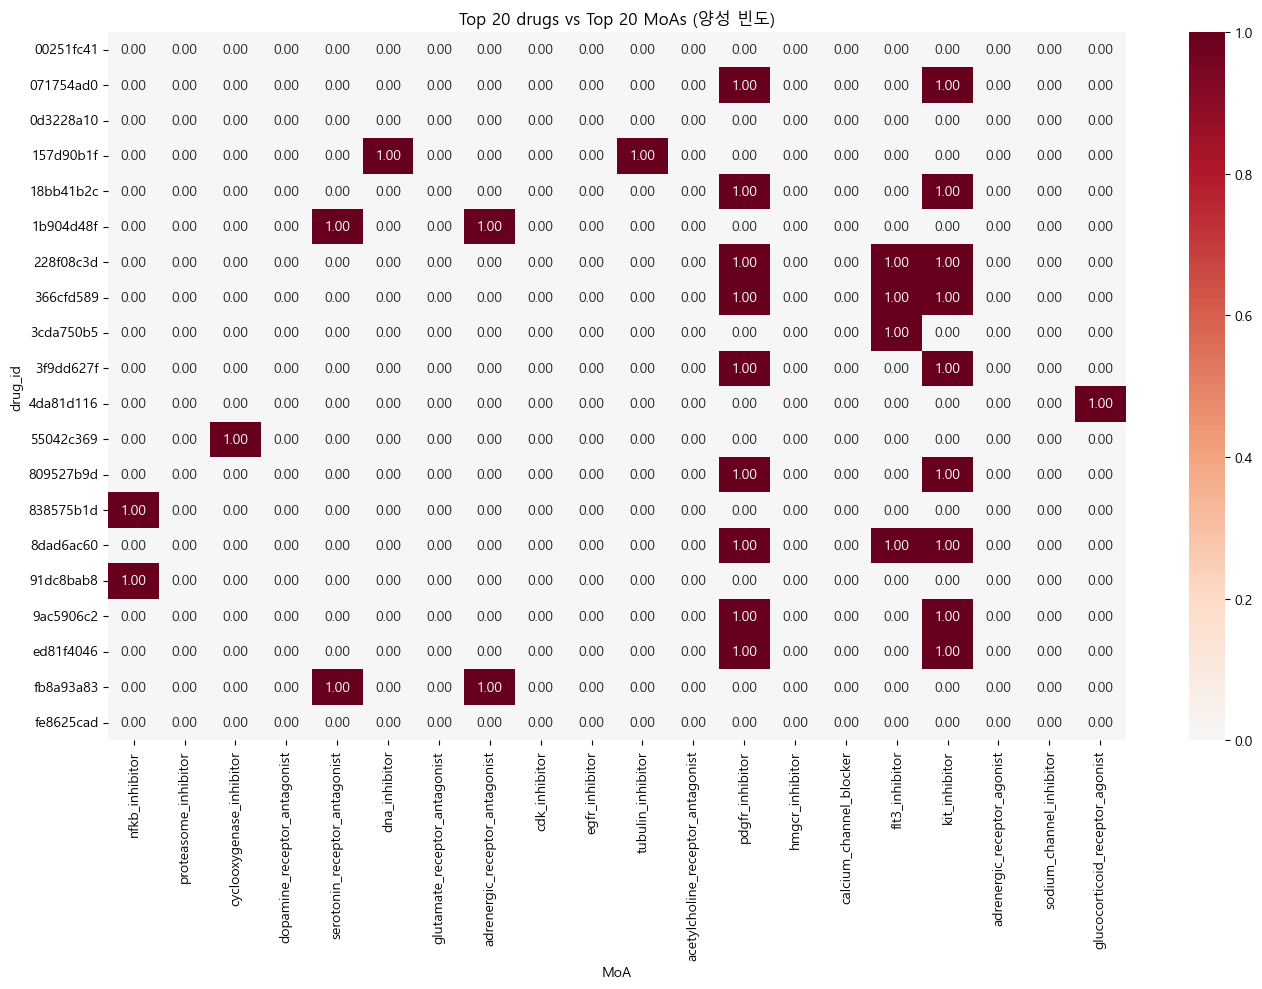

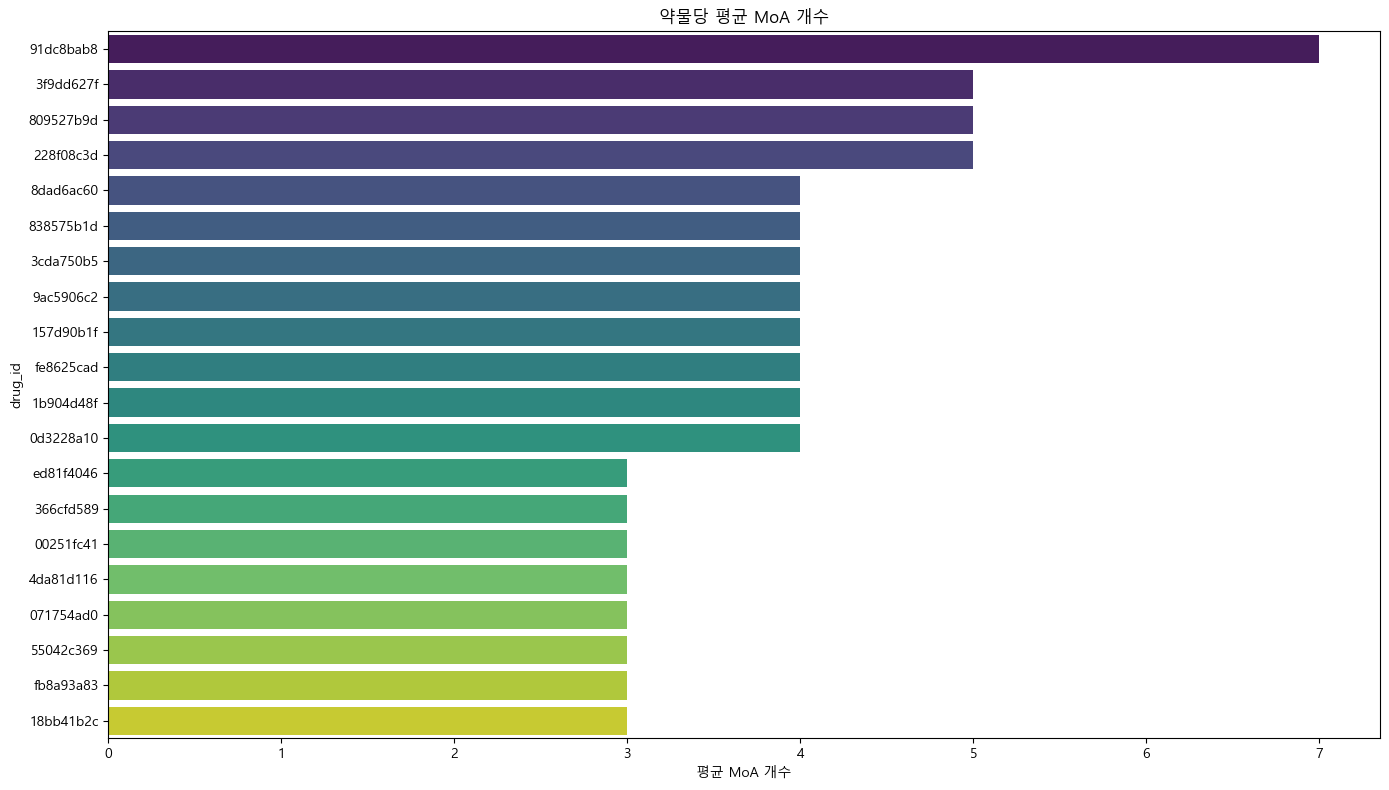

In [11]:
# 1. 약물별 MoA 발현 빈도 분석
moa_cols = [c for c in train_targets_scored.columns if c != "sig_id"]

df_train_copy["moa_count"] = df_train_copy[moa_cols].sum(axis=1)

# 약물당 평균 MoA 개수
drug_moa_summary = (
    df_train_copy.groupby("drug_id")["moa_count"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

drug_moa_summary["mean"] = drug_moa_summary["mean"].round(3)
print("=== 약물별 평균 MoA 개수 (상위 20개) ===")
display(drug_moa_summary.head(20))

# MoA별 양성 빈도
moa_freq = df_train_copy[moa_cols].mean().sort_values(ascending=False)
print("\n=== MoA별 양성 비율 상위 20개 ===")
display(moa_freq.head(20).to_frame(name="frequency"))

# 자주 나타나는 MoA 조합
df_train_copy["moa_combo"] = df_train_copy[moa_cols].apply(
    lambda row: " | ".join(row.index[row == 1].tolist()), axis=1)
combo_counts = df_train_copy["moa_combo"].value_counts().head(20)
print("\n=== 가장 자주 나타나는 MoA 조합 상위 20개 ===")
display(combo_counts.to_frame(name="count"))

# 히트맵: Top 20 drugs vs Top 20 MoAs (양성 빈도) [Top 20 Drugs vs Top 20 MoA Positive Frequency]
top_drugs = drug_moa_summary.head(20)["drug_id"].tolist()
top_moas = moa_freq.head(20).index.tolist()
heat_df = (
    df_train_copy.query("drug_id in @top_drugs")
    .groupby("drug_id")[top_moas]
    .mean()
)

plt.figure(figsize=(14, 10))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Top 20 drugs vs Top 20 MoAs (양성 빈도)")
plt.xlabel("MoA")
plt.ylabel("drug_id")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 약물당 평균 MoA 개수 바 차트 [ Top 20 Drugs by Average Number of Positive MoA ]
plt.figure(figsize=(14, 8))
sns.barplot(data=drug_moa_summary.head(20), x="mean", y="drug_id", palette="viridis")
plt.title("약물당 평균 MoA 개수")
plt.xlabel("평균 MoA 개수")
plt.ylabel("drug_id")
plt.tight_layout()
plt.show()

In [12]:
# c- 피처들만 추출하여 행별 평균 계산
c_cols = [col for col in df_train_copy.columns if col.startswith('c-')]
df_train_copy['c_mean'] = df_train_copy[c_cols].mean(axis=1)

# moa_count와 c_mean 사이의 상관계수 확인
correlation = df_train_copy[['moa_count', 'c_mean']].corr().iloc[0, 1]
print(f"MoA 개수와 세포 생존율 평균 사이의 상관계수: {correlation:.4f}")

MoA 개수와 세포 생존율 평균 사이의 상관계수: -0.2952


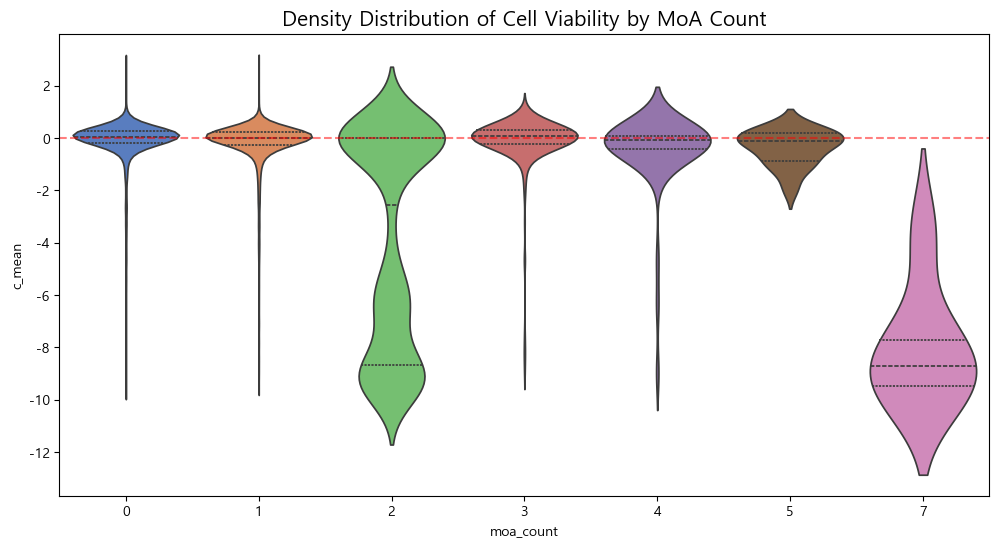

In [13]:
# 시각화
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_train_copy, x='moa_count', y='c_mean', inner="quartile", palette='muted')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Density Distribution of Cell Viability by MoA Count", fontsize=15)
plt.show()

In [14]:
# MoA 2개 구간 중 아래쪽(독성이 강한 그룹)에 속한 약물은 어떤 MoA 조합을 가지고 있는가
# moa_count가 2 -> drug_id별 평균 c_mean과 대표 moa_combo 추출
drug_level_df = df_train_copy[df_train_copy['moa_count'] == 2].groupby('drug_id').agg({
    'c_mean': 'mean',
    'moa_combo': 'first'  # 동일 drug_id는 moa_combo가 같으므로 first 사용
}).reset_index()

c_mean_vals = drug_level_df['c_mean']
    
# KDE(밀도 함수) 계산
kde = gaussian_kde(c_mean_vals)
x_range = np.linspace(c_mean_vals.min(), c_mean_vals.max(), 1000)
y_density = kde(x_range)

#  세포 생존율(c_mean) 기준으로 '독한 그룹'과 '순한 그룹' 나누기
mask = (x_range > -4) & (x_range < -1)
bottleneck_x = x_range[mask][np.argmin(y_density[mask])]
bottleneck_y = y_density[mask].min()

# 독한 약물 그룹 vs 순한 약물 그룹 분리
toxic_drugs = drug_level_df[drug_level_df['c_mean'] < bottleneck_x]
mild_drugs = drug_level_df[drug_level_df['c_mean'] >= bottleneck_x]

print(f"세포 생존율(c_mean) 기준으로 독한 그룹과 순한 그룹을 나누는 병목점: {bottleneck_x:.3f} (밀도: {bottleneck_y:.5f})")
print(f"독한 그룹에 속한 약물 수: {len(toxic_drugs)}")
print(f"순한 그룹에 속한 약물 수: {len(mild_drugs)}")


# 독한 그룹과 순한 그룹의 MoA 조합 분석
toxic_moa_combos = toxic_drugs['moa_combo'].value_counts().head(20)
mild_moa_combos = mild_drugs['moa_combo'].value_counts().head(20)
print("\n=== 독한 그룹에서 자주 나타나는 MoA 조합 상위 20개 ===")
display(toxic_moa_combos.to_frame(name="count"))
print("\n=== 순한 그룹에서 자주 나타나는 MoA 조합 상위 20개 ===")
display(mild_moa_combos.to_frame(name="count"))

세포 생존율(c_mean) 기준으로 독한 그룹과 순한 그룹을 나누는 병목점: -3.994 (밀도: 0.02070)
독한 그룹에 속한 약물 수: 4
순한 그룹에 속한 약물 수: 135

=== 독한 그룹에서 자주 나타나는 MoA 조합 상위 20개 ===


,count
moa_combo,
mtor_inhibitor | pi3k_inhibitor,3
nfkb_inhibitor | proteasome_inhibitor,1



=== 순한 그룹에서 자주 나타나는 MoA 조합 상위 20개 ===


,count
moa_combo,
dopamine_receptor_antagonist | serotonin_receptor_antagonist,10
insulin_sensitizer | ppar_receptor_agonist,6
dopamine_receptor_antagonist | serotonin_reuptake_inhibitor,4
fgfr_inhibitor | vegfr_inhibitor,4
flt3_inhibitor | jak_inhibitor,3
pdgfr_inhibitor | vegfr_inhibitor,3
egfr_inhibitor | tyrosine_kinase_inhibitor,3
mtor_inhibitor | pi3k_inhibitor,3
adrenergic_receptor_agonist | serotonin_receptor_agonist,2


#### 2. **세포주(Cell line) 특성별 응답 차이 (Cell-specific Analysis)**
    - mapping: train_master.csv 파일 사용 예정
    - 특정 약물이 특정 세포주(예: 간암 세포 vs 폐암 세포)에서만 유독 사멸 효과(c- 값의 급격한 저하)가 큰지 확인 
    : Boxplot으로 세포주 타입별로 세포주마다 반응이 극명하게 다른지 확인
___

In [15]:
# 1. ccle_name에서 마지막 단어(조직명) 추출하여 'tissue' 컬럼 만들기
# ccle_name이 'A375_SKIN' 이라면 '_'로 잘랐을 때 맨 뒤의 'SKIN'을 가져옵니다.
cell_info['tissue'] = cell_info['ccle_name'].str.split('_').str[-1]

# 2. 조직별로 어떤 세포주들이 있는지 확인 (딕셔너리 형태로 묶기)
# 이 딕셔너리를 사용하면 "조직명"만 입력해도 해당되는 모든 "ccle_name"을 찾을 수 있습니다.
tissue_group = cell_info.groupby('tissue')['ccle_name'].apply(list).to_dict()

# 3. 결과 요약 출력
print("=== 조직별 세포주 개수 요약 ===")
tissue_counts = cell_info['tissue'].value_counts()
print(tissue_counts)

# 4. 예시: 특정 조직(예: PANCREAS)에 속한 세포주 코드 확인
sample_tissue = list(tissue_group.keys())[0] # 첫 번째 조직 예시
print(f"\n💡 '{sample_tissue}' 조직에 속한 세포주 리스트:")
print(tissue_group[sample_tissue])

=== 조직별 세포주 개수 요약 ===
tissue
LUNG                 15
TRACT                11
OVARY                10
INTESTINE             7
PANCREAS              6
SKIN                  6
ENDOMETRIUM           6
LIVER                 6
BONE                  5
KIDNEY                5
SYSTEM                4
THYROID               4
TISSUE                3
STOMACH               3
BREAST                3
GANGLIA               2
OESOPHAGUS            2
PLEURA                1
prism invariant 1     1
prism invariant 2     1
prism invariant 3     1
prism invariant 4     1
GLAND                 1
Name: count, dtype: int64

💡 'BONE' 조직에 속한 세포주 리스트:
['SJSA1_BONE', 'SW1353_BONE', 'CADOES1_BONE', 'SKES1_BONE', 'HOS_BONE']


In [20]:
# 조직별로 세포주 그룹으로 나누기 [lung, Tract, Ovary, INTESTINE, PANCREAS, SKIN, ENDOMETRIUM, LIVER, BONE, KIDNEY]

target_tissues = ['LUNG', 'TRACT', 'OVARY', 'INTESTINE', 'PANCREAS',
                  'SKIN', 'ENDOMETRIUM', 'LIVER', 'BONE', 'KIDNEY']

tissue_groups = {tissue: tissue_group.get(tissue, []) for tissue in target_tissues}

print("\n=== 조직별 세포주 그룹 ===")
for tissue, rids in tissue_groups.items():
    print(f"{tissue}: {tissue_groups[tissue]} 세포주(총: {len(rids)}개)")
    print("-" * 40)


=== 조직별 세포주 그룹 ===
LUNG: ['NCIH1299_LUNG', 'NCIH460_LUNG', 'SBC5_LUNG', 'NCIH520_LUNG', 'SW1573_LUNG', 'COLO668_LUNG', 'NCIH292_LUNG', 'RERFLCAI_LUNG', 'NCIH1435_LUNG', 'ABC1_LUNG', 'NCIH1373_LUNG', 'EBC1_LUNG', 'SKMES1_LUNG', 'CAL12T_LUNG', 'DMS273_LUNG'] 세포주(총: 15개)
----------------------------------------
TRACT: ['SNU1076_UPPER_AERODIGESTIVE_TRACT', 'VMCUB1_URINARY_TRACT', 'YD38_UPPER_AERODIGESTIVE_TRACT', 'SW1710_URINARY_TRACT', 'PECAPJ15_UPPER_AERODIGESTIVE_TRACT', 'RT4_URINARY_TRACT', 'HUCCT1_BILIARY_TRACT', 'SNU1196_BILIARY_TRACT', 'T24_URINARY_TRACT', '647V_URINARY_TRACT', 'YD10B_UPPER_AERODIGESTIVE_TRACT'] 세포주(총: 11개)
----------------------------------------
OVARY: ['JHOC5_OVARY', 'EFO27_OVARY', 'OVK18_OVARY', 'TOV112D_OVARY', 'RMGI_OVARY', 'OV7_OVARY', 'HEYA8_OVARY', 'ES2_OVARY', 'A2780_OVARY', 'OAW42_OVARY'] 세포주(총: 10개)
----------------------------------------
INTESTINE: ['SNU61_LARGE_INTESTINE', 'LS513_LARGE_INTESTINE', 'HT55_LARGE_INTESTINE', 'LS180_LARGE_INTESTINE', 'HCC

In [ ]:
# 세포주(Cell line) 특성별 응답 차이 분석
cell_line_cols = [col for col in df_train_master_cell.columns if col in set(cell_info['ccle_name'])]
if len(cell_line_cols) == 0:
    cell_line_cols = [col for col in df_train_master_cell.columns if col.startswith("c-")]

print("사용할 세포주 피처 개수:", len(cell_line_cols))

# 세포주별 응답을 long format으로 변환
id_vars = ["sig_id", "drug_id", "cp_type", "cp_time", "cp_dose"]
if cell_line_cols[0].startswith("c-"):
    df_cell_response = (
        df_train_master_cell.melt(id_vars=id_vars,
                                  value_vars=cell_line_cols,
                                  var_name="rid",
                           value_name="cell_viability")
        .merge(cell_info, on="rid", how="left")
    )
    df_cell_response["cell_line"] = df_cell_response["ccle_name"]
else:
    meta_cols = ["disease", "site", "primary_disease", "cancer_type"]
    meta_present = [c for c in meta_cols if c in cell_info.columns]
    df_cell_response = (
        df_train_master_cell.melt(id_vars=id_vars,
                                  value_vars=cell_line_cols,
                                  var_name="cell_line",
                                  value_name="cell_viability")
        .merge(cell_info[["ccle_name"] + meta_present], left_on="cell_line", right_on="ccle_name", how="left")
    )
    if "tissue" not in df_cell_response.columns:
        df_cell_response["tissue"] = df_cell_response["ccle_name"].str.split("_").str[-1]

사용할 세포주 피처 개수: 100


In [51]:
# 1. cell_info 테이블 자체에서 BONE 조직을 가진 세포주 리스트 확보
# (cell_info에 'tissue' 혹은 'site' 등 조직 정보를 담은 컬럼이 있다고 가정)
bone_cell_list = cell_info[cell_info['ccle_name'].str.contains('BONE', case=False, na=False)]['ccle_name'].tolist()

# 만약 cell_info에 tissue 컬럼이 따로 있다면 그것을 활용
if 'tissue' in cell_info.columns:
    bone_cell_list = cell_info[cell_info['tissue'].str.upper() == 'BONE']['ccle_name'].tolist()

print(f"cell_info에서 찾은 BONE 세포주 개수: {len(bone_cell_list)}")

# 2. df_cell_response에서 해당 세포주들의 tissue를 'BONE'으로 업데이트
# (이미 melt가 된 상태라면 'cell_line' 컬럼에 세포주 이름이 들어있음)
mask = df_cell_response['cell_line'].isin(bone_cell_list)
df_cell_response.loc[mask, 'tissue'] = 'BONE'

# 3. 다시 필터링 시도
target_tissues = ['LUNG', 'TRACT', 'OVARY', 'INTESTINE', 'PANCREAS', 
                  'SKIN', 'ENDOMETRIUM', 'LIVER', 'KIDNEY', 'BONE']

df_final = df_cell_response[df_cell_response['tissue'].isin(target_tissues)].reset_index(drop=True)

print(f"최종 확인 - 포함된 조직: {df_final['tissue'].unique()}")

cell_info에서 찾은 BONE 세포주 개수: 5
최종 확인 - 포함된 조직: ['OVARY' 'INTESTINE' 'LIVER' 'TRACT' 'PANCREAS' 'ENDOMETRIUM' 'LUNG'
 'KIDNEY' 'SKIN' 'BONE']


In [52]:
# target_tissues에 포함된 데이터만 남기기
df_cell_response = df_cell_response[df_cell_response['tissue'].isin(target_tissues)].reset_index(drop=True)

print(f"필터링 후 남은 조직: {df_cell_response['tissue'].unique()}")
print(f"최종 데이터 행 수: {len(df_cell_response)}")

필터링 후 남은 조직: ['OVARY' 'INTESTINE' 'LIVER' 'TRACT' 'PANCREAS' 'ENDOMETRIUM' 'LUNG'
 'KIDNEY' 'SKIN' 'BONE']
최종 데이터 행 수: 1833678


In [58]:
# 반응 변동성이 큰 세포주 Top 10 [Top 10 cell lines by cell viability variance]
cell_line_stats = (
    df_cell_response.groupby(["cell_line", "tissue"])["cell_viability"]
    .agg(["median", "var", "count"])
)
display(cell_line_stats)

,,median,var,count
cell_line,tissue,,,
647V_URINARY_TRACT,TRACT,0.00640,4.712889,23814
A101D_SKIN,SKIN,-0.02245,4.658388,23814
A2058_SKIN,SKIN,-0.00665,5.277933,23814
A2780_OVARY,OVARY,-0.02535,2.709719,23814
A375_SKIN,SKIN,0.00650,5.148048,23814
ABC1_LUNG,LUNG,-0.01375,4.439890,23814
BFTC909_KIDNEY,KIDNEY,0.00570,4.138237,23814
CADOES1_BONE,BONE,-0.02380,3.560771,23814
CAKI1_KIDNEY,KIDNEY,-0.00930,4.088189,23814


#### 추가 1] 조직(Tissue)별 응답 차이 Boxplot
- 조직별 `cell_viability` 분포 비교
- 충분한 샘플이 있는 조직만 포함해 안정적인 시각화

In [59]:
# 1. 약물(drug_id)별로 cell_viability의 표준편차(std) 계산
# 표준편차가 크다 = 세포주마다 반응이 제각각이다 = 특정 세포 특이적일 가능성이 높다
drug_variance = df_cell_response.groupby('drug_id')['cell_viability'].std().sort_values(ascending=False)

# 2. 상위 10개 약물 ID 추출
top_10_drugs = drug_variance.head(10).index.tolist()
print("반응 차이가 가장 큰 Top 10 약물:", top_10_drugs)

# 3. Top 1 약물(가장 반응이 극명하게 갈리는 약물) 선정
top_1_drug = top_10_drugs[0]
print(f"분석 대상 약물 (Top 1): {top_1_drug}")

반응 차이가 가장 큰 Top 10 약물: ['f6bcf8339', '58c670daa', '8e6a6f400', 'ea2734432', '847fbc822', '376c56233', '74fed7806', '394c2d495', '7d50d31a6', 'b5e8fd5b5']
분석 대상 약물 (Top 1): f6bcf8339


In [60]:
print(df_cell_response['tissue'].unique())

['OVARY' 'INTESTINE' 'LIVER' 'TRACT' 'PANCREAS' 'ENDOMETRIUM' 'LUNG'
 'KIDNEY' 'SKIN' 'BONE']


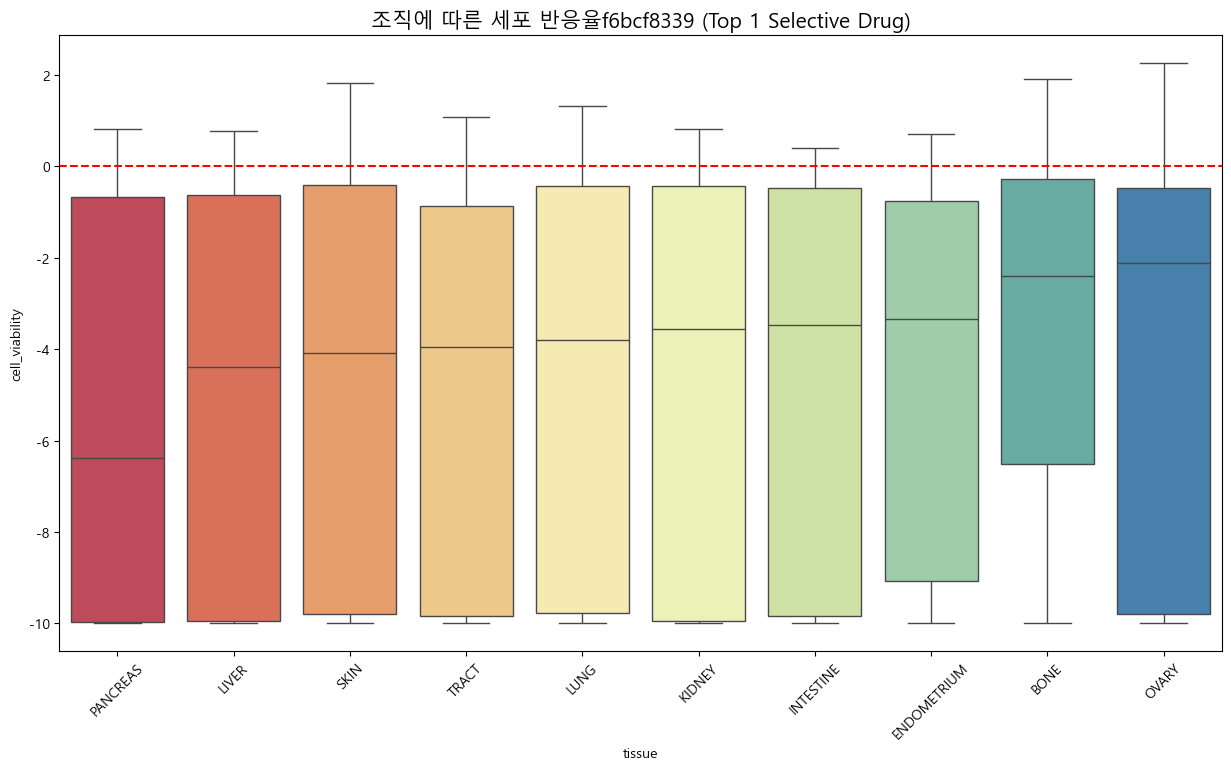

In [61]:
# 해당 약물 데이터만 필터링
target_tissues = ['LUNG', 'TRACT', 'OVARY', 'INTESTINE', 'PANCREAS', 
                  'SKIN', 'ENDOMETRIUM', 'LIVER', 'BONE', 'KIDNEY']
df_top1 = df_cell_response[
    (df_cell_response['drug_id'] == top_1_drug) & 
    (df_cell_response['tissue'].isin(target_tissues))
].copy()

# 시각화: 조직별 Boxplot [Cell Response by Tissue for {top_1_drug} (Top 1 Selective Drug)]
plt.figure(figsize=(15, 8))
# 중앙값 기준으로 정렬하여 시각적 효과 극대화
order = df_top1.groupby('tissue')['cell_viability'].median().sort_values().index

sns.boxplot(data=df_top1, x='tissue', y='cell_viability', order=order, palette='Spectral')
plt.xticks(rotation=45)
plt.title(f"조직에 따른 세포 반응율{top_1_drug} (Top 1 Selective Drug)", fontsize=15)
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

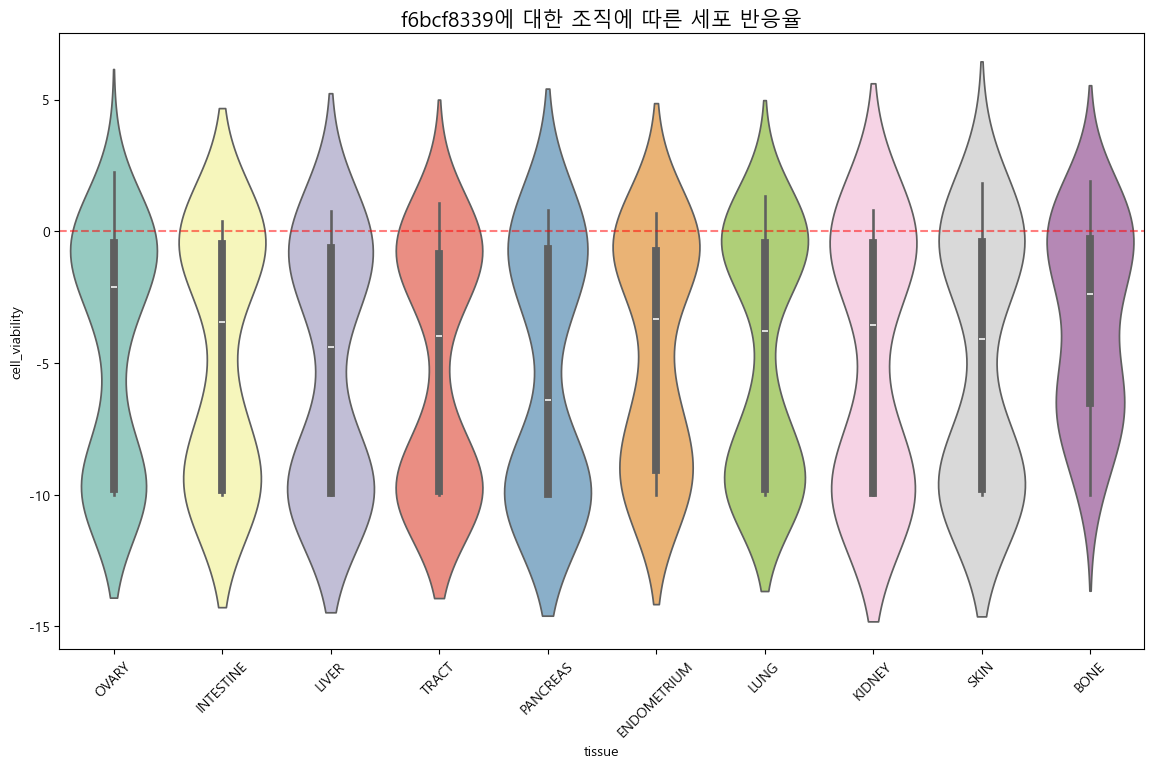

In [62]:
# Top 1 약물에 대한 세포주별 반응 분포 시각화 (Violin Plot)
top_drug = top_1_drug
df_top_drug = df_cell_response[df_cell_response['drug_id'] == top_drug]
plt.figure(figsize=(14, 8))
sns.violinplot(data=df_top_drug, x='tissue', y='cell_viability', palette='Set3')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title(f"{top_drug}에 대한 조직에 따른 세포 반응율", fontsize=15)
plt.xticks(rotation=45)
plt.show()

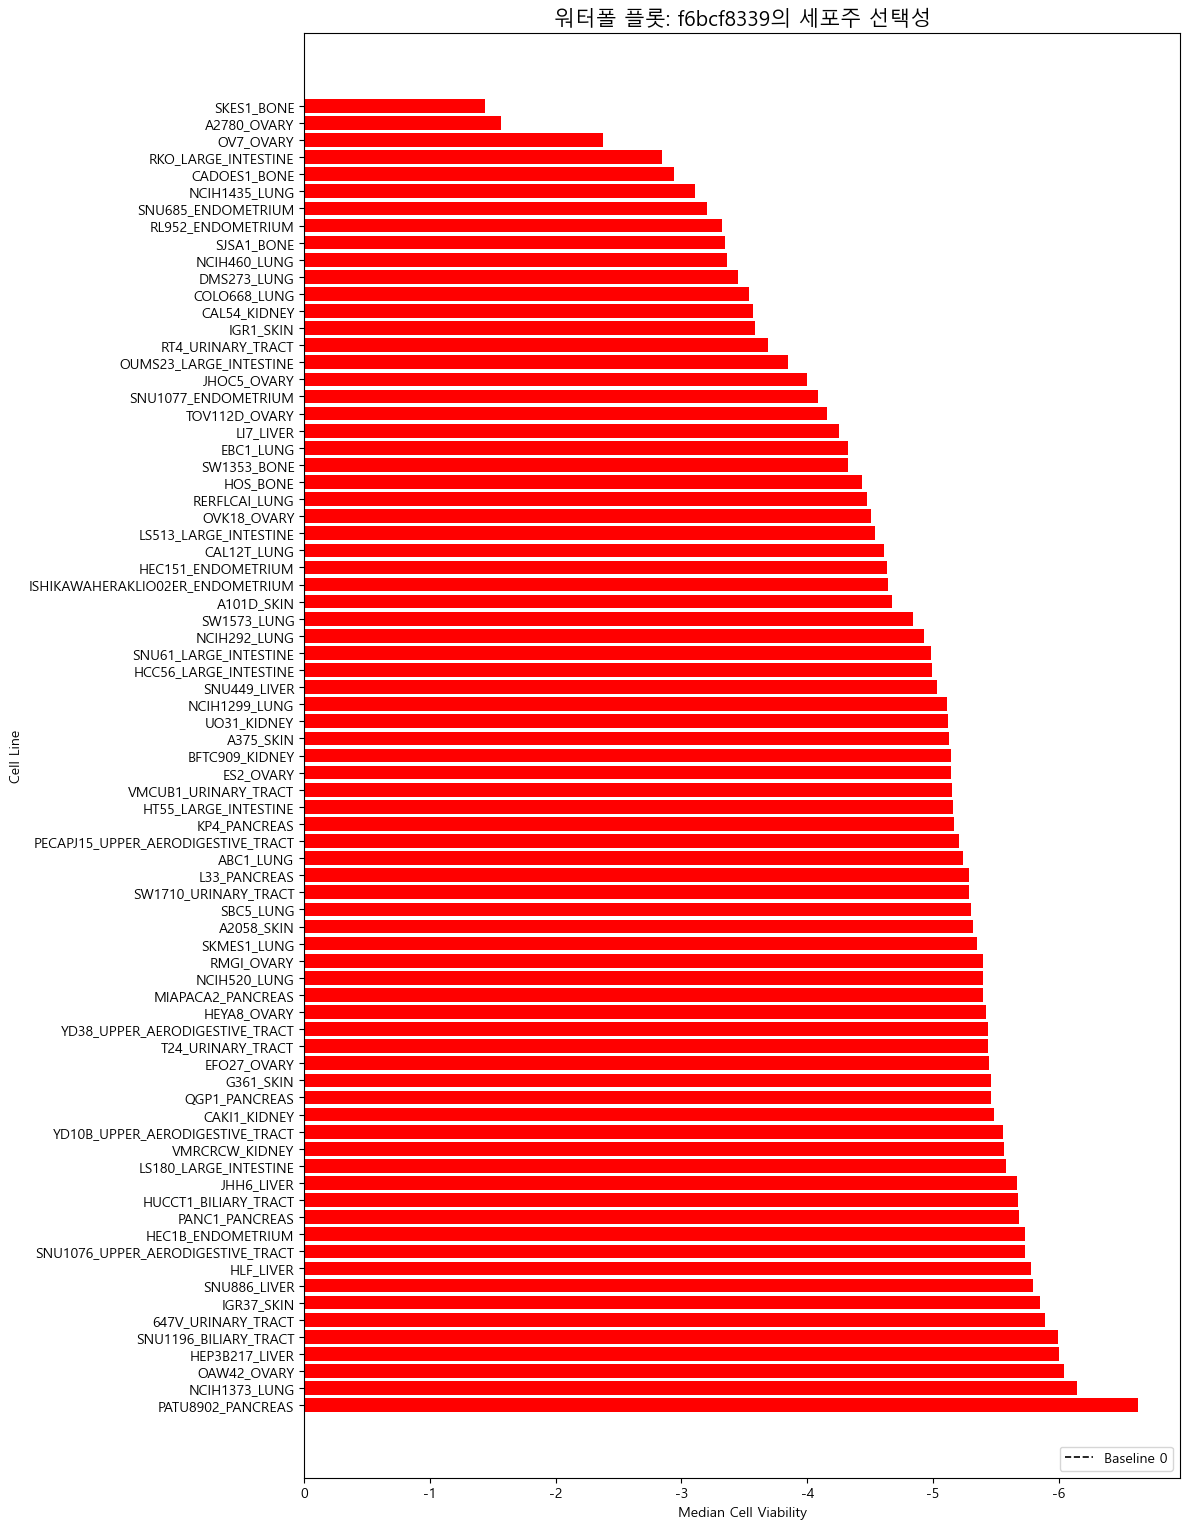

In [63]:
# Top 1 약물에 대해 세포주별로 정렬
df_waterfall = (
    df_top1.groupby('cell_line')['cell_viability']
    .median()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(12, max(6, len(df_waterfall) * 0.2)))
colors = ['red' if val < 0 else 'gray' for val in df_waterfall['cell_viability']]
plt.barh(
    y=df_waterfall['cell_line'],
    width=df_waterfall['cell_viability'],
    left=0,
    color=colors
)

ax = plt.gca()
min_val = df_waterfall['cell_viability'].min()
ax.set_xlim(0, min_val * 1.05)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2, label='Baseline 0')

plt.xlabel('Median Cell Viability')
plt.ylabel('Cell Line')
plt.title(f"워터폴 플롯: {top_1_drug}의 세포주 선택성", fontsize=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### 추가 2. 약물의 세포주 특이성 증명 - ANOVA P-value Ranking
- 동일 약물에 대해 조직별 응답 차이가 유의한지 ANOVA로 검증합니다.
- p-value가 작을수록 조직 특이성이 큰 약물입니다.

In [64]:
# 동일 약물, 동일 세포주에 대한 중복 데이터가 있다면 평균으로 병합
df_cleaned = df_cell_response.groupby(['tissue', 'drug_id', 'ccle_name'])['cell_viability'].mean().reset_index()

In [65]:
# 1. 데이터 준비 (df_cleaned 사용)
# 분석 대상: 조직(tissue)별 cell_viability
tissue_groups = [group['cell_viability'].values for name, group in df_cleaned.groupby('tissue')]

# 2. 전체 조직 간 분산 분석 (One-way ANOVA) 실행
f_val_total, p_val_total = stats.f_oneway(*tissue_groups)

# 3. 효과 크기 (Eta-squared) 계산
global_mean = df_cleaned['cell_viability'].mean()
ss_total = np.sum((df_cleaned['cell_viability'] - global_mean)**2)

# 조직 간 분산 (Between-group Sum of Squares)
ss_between = 0
for name, group in df_cleaned.groupby('tissue'):
    n = len(group)
    group_mean = group['cell_viability'].mean()
    ss_between += n * (group_mean - global_mean)**2

eta_squared_total = ss_between / ss_total if ss_total != 0 else 0

# 4. 결과 출력
print("=== [1] 전체 조직 간 생존율 차이 분석 ===")
print(f"F-value      : {f_val_total:.4f}")
print(f"p-value      : {p_val_total:.4e}")
print(f"Eta-squared(η²): {eta_squared_total:.4f}")

# 해석
if eta_squared_total < 0.01:
    interp = "무시할 만한 수준 (Negligible)"
elif eta_squared_total < 0.06:
    interp = "작은 효과 (Small) - 조직 간 차이가 존재하나 미미함"
elif eta_squared_total < 0.14:
    interp = "중간 효과 (Medium)"
else:
    interp = "큰 효과 (Large)"

print(f"해석         : 전체 변동 중 조직(Tissue)의 차이가 설명하는 비중은 약 {eta_squared_total*100:.2f}%로, {interp}입니다.")
print("-" * 50)

# [2] 사후 검정 
print(f"=== [2] 전체 조직 간 영향력 확인 ===")
print("조직 간 차이가 유의미하지 않으므로, 사후 검정은 생략합니다.")
print("-" * 50)

print("결론: 조직 자체의 차이만으로는 약물 반응을 설명하기 부족하므로, 조직 내 약물 간 차이를 분석필요.")

=== [1] 전체 조직 간 생존율 차이 분석 ===
F-value      : 14.4520
p-value      : 1.1656e-23
Eta-squared(η²): 0.0005
해석         : 전체 변동 중 조직(Tissue)의 차이가 설명하는 비중은 약 0.05%로, 무시할 만한 수준 (Negligible)입니다.
--------------------------------------------------
=== [2] 전체 조직 간 영향력 확인 ===
조직 간 차이가 유의미하지 않으므로, 사후 검정은 생략합니다.
--------------------------------------------------
결론: 조직 자체의 차이만으로는 약물 반응을 설명하기 부족하므로, 조직 내 약물 간 차이를 분석필요.


## 특정 조직 내 약물 비교
___
어느 조직에서 유의미한 약물 반응은 보이지 않으며, 각 조직 안에서 해당 약물이 유독 튀게 유의미하게 보이는가를 비교하는 작업.

In [67]:
# 특정 조직 내 약물 비교
anova_results = []
min_drug_threshold = 20

# ANOVA p-value ranking: drug_id별 tissue 효과 검증
# df_cleaned(ccle_name 평균) 대신 trt_cp 원시 데이터 사용
df_src = df_cell_response[df_cell_response['cp_type'] == 'trt_cp'].copy()

# 조직별로 약물 간 차이 분석 (ANOVA + 효과크기)
for tissue_name, group in df_src.groupby('tissue'):
    n_unique_drugs = group['drug_id'].nunique()
    n_cell_lines = group['ccle_name'].nunique()
    
    # 약물 종류가 2개 미만이거나, 데이터가 너무 적은 조직은 분석에서 제외 (통계적 신뢰도 확보하기 위함.)
    if n_unique_drugs < 2 or len(group) < min_drug_threshold:
        continue
        
    try:
        # 세포주가 2개 이상인 조직은 약물-세포주별 평균으로 정제하여 분석 (노이즈 감소)
          # 동일한 세포주(ccle_name)에서 동일한 약물(drug_id)에 대한 여러 측정값이 있다면 평균으로 병합
        if n_cell_lines >= 2:
            # [CASE 1] 데이터가 풍부한 조직: 약물-세포주별 평균으로 정제 (가장 정확)
            refined_group = group.groupby(['drug_id', 'ccle_name'])['cell_viability'].mean().reset_index()
            analysis_type = "Refined (Cell-line Mean)"
        else:
            # [CASE 2] 세포주가 1개뿐인 조직: 원시 데이터 그대로 사용 (시간/용량)
            refined_group = group
            analysis_type = "Raw (Time/Dose)"

        # ANOVA 데이터 묶기
        groups_list = [subgroup['cell_viability'].values for _, subgroup in refined_group.groupby('drug_id')]
        
        # 2개 이상의 샘플을 가진 약물 그룹만 포함
        groups_list = [g for g in groups_list if len(g) >= 1] 

        if len(groups_list) < 2: continue

        # ANOVA 실행
        f_val, p_val = stats.f_oneway(*groups_list)

        # 효과크기 검정(에타 제곱)
        ss_between = sum(len(g) * (np.mean(g) - np.mean(refined_group['cell_viability']))**2 for g in groups_list)
        ss_total = sum((x - np.mean(refined_group['cell_viability']))**2 for g in groups_list for x in g)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0
        
        anova_results.append({
            'tissue_name': tissue_name,
            'n_cell_lines': n_cell_lines,
            'n_drugs': n_unique_drugs,
            'anova_Fvalue': f_val,
            'anova_pvalue': p_val,
            'eta_squared': eta_squared,
            'analysis_method': analysis_type
        })
    except Exception as e:
        print(f"Error in {tissue_name}: {e}")

# 결과 정리
final_anova_df = pd.DataFrame(anova_results).sort_values('anova_Fvalue', ascending=False).reset_index(drop=True)
display(final_anova_df)

,tissue_name,n_cell_lines,n_drugs,anova_Fvalue,anova_pvalue,eta_squared,analysis_method
0,TRACT,11,3288,73.399973,0.0,0.880064,Refined (Cell-line Mean)
1,LUNG,15,3288,57.206357,0.0,0.803340,Refined (Cell-line Mean)
2,SKIN,6,3288,39.411469,0.0,0.887386,Refined (Cell-line Mean)
3,OVARY,10,3288,34.220396,0.0,0.791715,Refined (Cell-line Mean)
4,PANCREAS,6,3288,28.247391,0.0,0.849573,Refined (Cell-line Mean)
5,INTESTINE,7,3288,27.712030,0.0,0.821977,Refined (Cell-line Mean)
6,KIDNEY,5,3288,25.018275,0.0,0.862120,Refined (Cell-line Mean)
7,ENDOMETRIUM,6,3288,24.851683,0.0,0.832463,Refined (Cell-line Mean)
8,LIVER,6,3288,21.681746,0.0,0.812560,Refined (Cell-line Mean)
9,BONE,5,3288,12.290857,0.0,0.754407,Refined (Cell-line Mean)


## **사후검정**
___
1) 전체적인 사후검정 실시
2) top 10 약물로만 사후검정 실시

In [68]:
# 사후 검정(Tukey's HSD) 실행
posthoc_summary = []
significant_pairs_dict = {} # 특정 조직의 상세 결과 확인용

for index, row in final_anova_df.iterrows():
    tissue = row['tissue_name']
    n_cells = row['n_cell_lines']
    
    # [1] 해당 조직 데이터 추출
    tissue_data = df_src[df_src['tissue'] == tissue].copy()
    
    if n_cells >= 2:
        # OVARY, LUNG 등 (Multi-cell): 약물-세포주 평균 데이터로 분석
         # 동일한 세포주(ccle_name)에서 동일한 약물(drug_id)에 대한 여러 측정값이 있다면 평균으로 병합
        test_data = tissue_data.groupby(['drug_id', 'ccle_name'])['cell_viability'].mean().reset_index()
        group_type = "다중 세포주 (일관성)"
    else:
        # SKIN, LIVER 등 (Single-cell): 시간/용량 원본 데이터로 분산 확보 (NaN 방지)
        test_data = tissue_data
        group_type = "단일 세포주 (특이성)"
        
    # [2] 상위 10개 약물 추출 (중앙값 기준)
    top_10_drugs = test_data.groupby('drug_id')['cell_viability'].median().sort_values().head(10).index
    target_data = test_data[test_data['drug_id'].isin(top_10_drugs)]
    
    try:
        # [3] Tukey HSD 검정 실행
        tukey = pairwise_tukeyhsd(endog=target_data['cell_viability'], 
                                  groups=target_data['drug_id'], 
                                  alpha=0.05)
        
        # [4] 결과 데이터프레임 변환 및 Reject=True 필터링
         # Reject=True : 유의미한 약물의 쌍만을 출력
        tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
        sig_results = tukey_df[tukey_df['reject'] == True].copy()
        
        # [5] 상세 결과 저장
        significant_pairs_dict[tissue] = sig_results
        
        # [6] 요약표 작성을 위한 최고 차이 조합 찾기
        if not sig_results.empty:
            # meandiff 절대값이 가장 큰(차이가 가장 극심한) 조합 추출
            sig_results['abs_meandiff'] = sig_results['meandiff'].abs()
            top_pair = sig_results.sort_values('abs_meandiff', ascending=False).iloc[0]
            top_pair_str = f"{top_pair['group1']} vs {top_pair['group2']} (차이: {top_pair['abs_meandiff']:.4f})"
        else:
            top_pair_str = "유의미한 차이 없음"
            
        posthoc_summary.append({
            '조직명 (Tissue)': tissue,
            '조직 특성': group_type,
            '유의미한 약물 쌍 (개)': len(sig_results),
            '가장 극명한 효능 차이를 보인 약물 쌍': top_pair_str
        })
        
    except Exception as e:
        print(f"[{tissue}] 사후검정 중 오류 발생: {e}")

# 최종본
summary_df = pd.DataFrame(posthoc_summary)
display(summary_df)

,조직명 (Tissue),조직 특성,유의미한 약물 쌍 (개),가장 극명한 효능 차이를 보인 약물 쌍
0,TRACT,다중 세포주 (일관성),2,379302187 vs 4b798dda1 (차이: 2.0343)
1,LUNG,다중 세포주 (일관성),0,유의미한 차이 없음
2,SKIN,다중 세포주 (일관성),0,유의미한 차이 없음
3,OVARY,다중 세포주 (일관성),0,유의미한 차이 없음
4,PANCREAS,다중 세포주 (일관성),2,1ac3046e2 vs 379302187 (차이: 2.7150)
5,INTESTINE,다중 세포주 (일관성),0,유의미한 차이 없음
6,KIDNEY,다중 세포주 (일관성),0,유의미한 차이 없음
7,ENDOMETRIUM,다중 세포주 (일관성),0,유의미한 차이 없음
8,LIVER,다중 세포주 (일관성),0,유의미한 차이 없음
9,BONE,다중 세포주 (일관성),0,유의미한 차이 없음



[분석 결과 1] 약물 변별력이 가장 큰 조직 (Between-Drug η²가 높은 곳): ['TRACT', 'LUNG', 'SKIN']


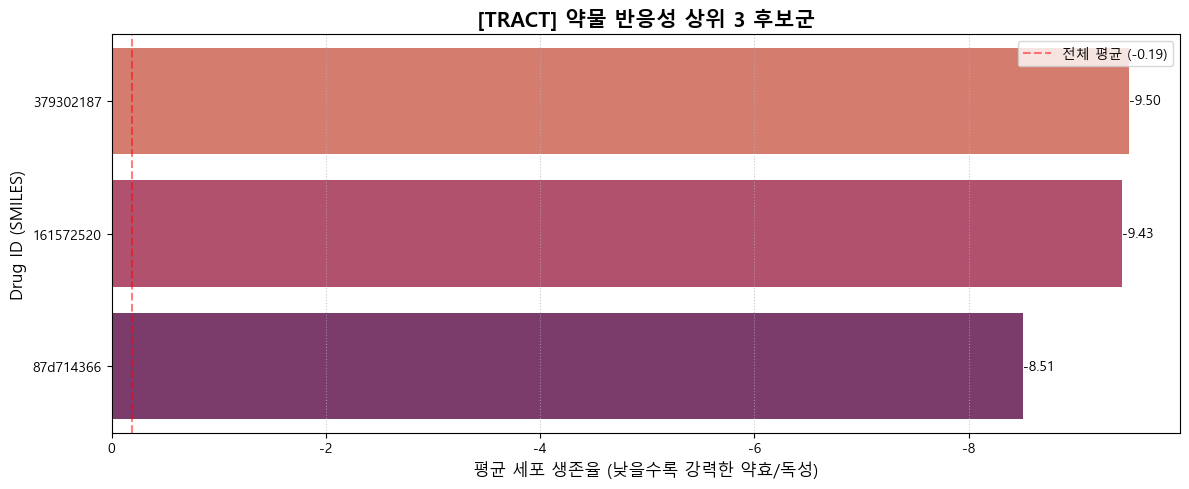

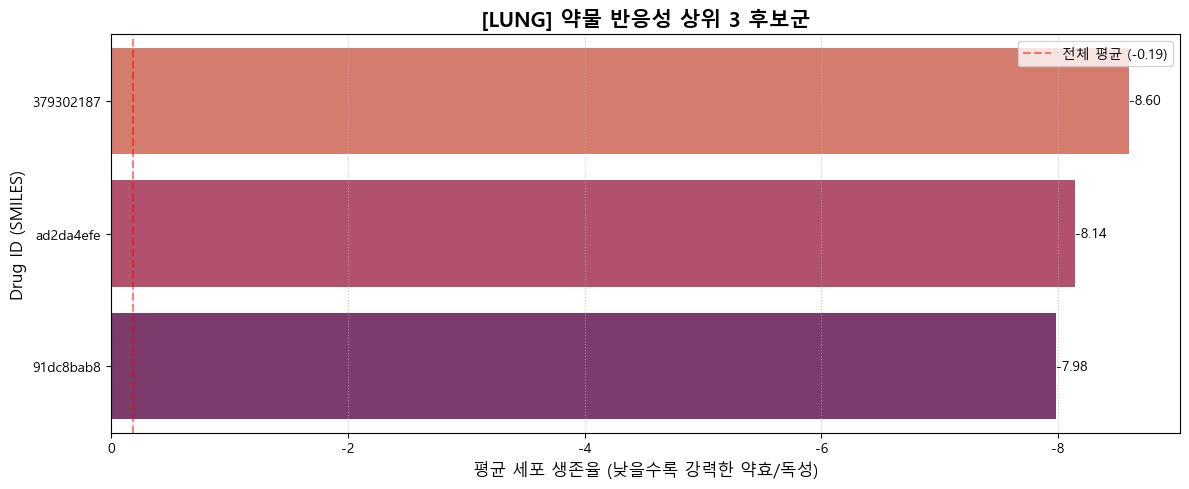

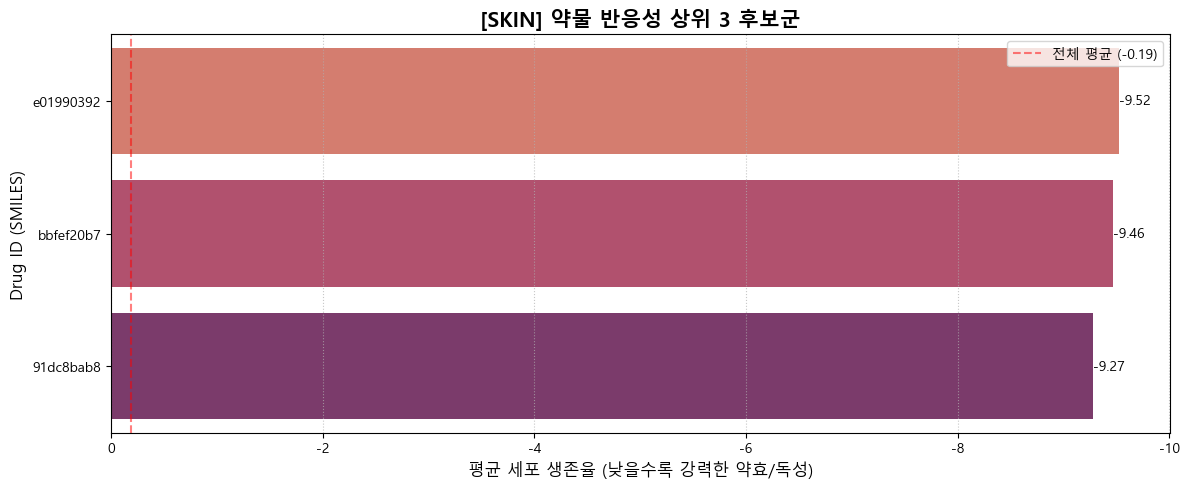


[분석 결과 2] 약물 변별력이 상대적으로 낮은 조직: ['ENDOMETRIUM', 'LIVER', 'BONE']


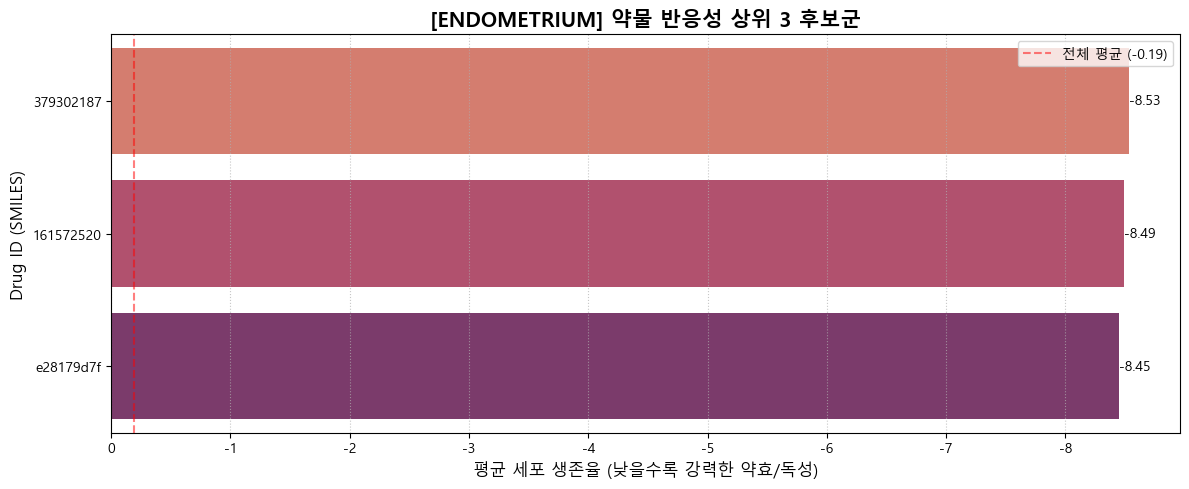

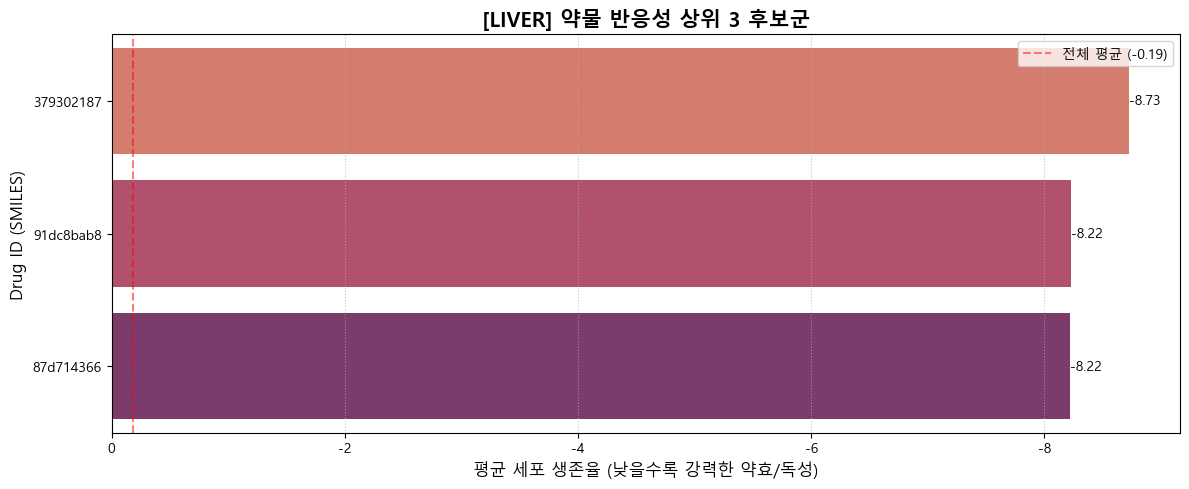

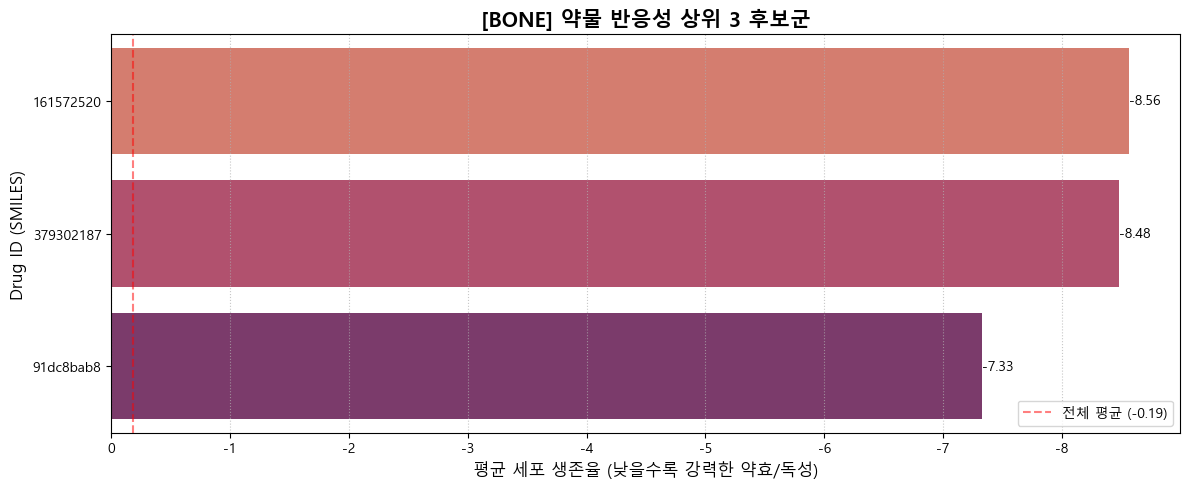

In [69]:
# 차이가 큰 조직 3개 추출, 낮은 조직 3개 추출하여 그 안에서 약물의 효능 비교 및 분석할 예정
anova_df = pd.DataFrame(anova_results).sort_values('anova_Fvalue', ascending=False).reset_index(drop=True)

top_diff_tissues = anova_df.head(3)['tissue_name'].tolist()
low_diff_tissues = anova_df.tail(3)['tissue_name'].tolist()

def plot_top_tissue_drugs(df, tissue_name, top_n=3):
    # 해당 조직 데이터 필터링
    tissue_data = df[df['tissue'] == tissue_name]
    
    # 약물별 평균 생존율 계산 및 정렬 (낮을수록 반응이 좋은 것)
    drug_effects = tissue_data.groupby('drug_id')['cell_viability'].mean().sort_values()
    top_drugs = drug_effects.head(top_n)
    
    # 그래프 시각화
    plt.figure(figsize=(12, 5))
    colors = sns.color_palette("flare", n_colors=top_n) 
    sns.barplot(x=top_drugs.values, y=top_drugs.index, palette=colors)
    plt.title(f"[{tissue_name}] 약물 반응성 상위 {top_n} 후보군", fontsize=15, fontweight='bold')
    plt.xlabel("평균 세포 생존율 (낮을수록 강력한 약효/독성)", fontsize=12)
    plt.ylabel("Drug ID (SMILES)", fontsize=12)
    # 막대 옆에 값 표사
    for i, val in enumerate(top_drugs.values):
        plt.text(val, i, f"{val:.2f}", va='center', ha='left', fontsize=10)
    # 전체 평균선 표시
    plt.axvline(x=global_mean, color='red', linestyle='--', alpha=0.5, label=f'전체 평균 ({global_mean:.2f})')
    # x축 반전
    plt.gca().invert_xaxis()
    plt.legend()
    plt.grid(axis='x', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 반복문 활용한 시각화 진행
print(f"\n[분석 결과 1] 약물 변별력이 가장 큰 조직 (Between-Drug η²가 높은 곳): {top_diff_tissues}")
for tissue in top_diff_tissues:
    plot_top_tissue_drugs(df_cleaned, tissue, top_n=3)

print(f"\n[분석 결과 2] 약물 변별력이 상대적으로 낮은 조직: {low_diff_tissues}")
for tissue in low_diff_tissues:
    plot_top_tissue_drugs(df_cleaned, tissue, top_n=3)

### **조직에 영향을 미치는 약물(top 10) boxplot**
___
유의미한 상위 조직 3개 (top_tissues: 3) / 상대적으로 낮은 조직 3개(Bottom_tissues: 3)

약물 간 차이가 가장 큰 조직 (상위 3개): ['TRACT', 'LUNG', 'SKIN']
약물 간 차이가 가장 작은 조직 (하위 3개): ['ENDOMETRIUM', 'LIVER', 'BONE']


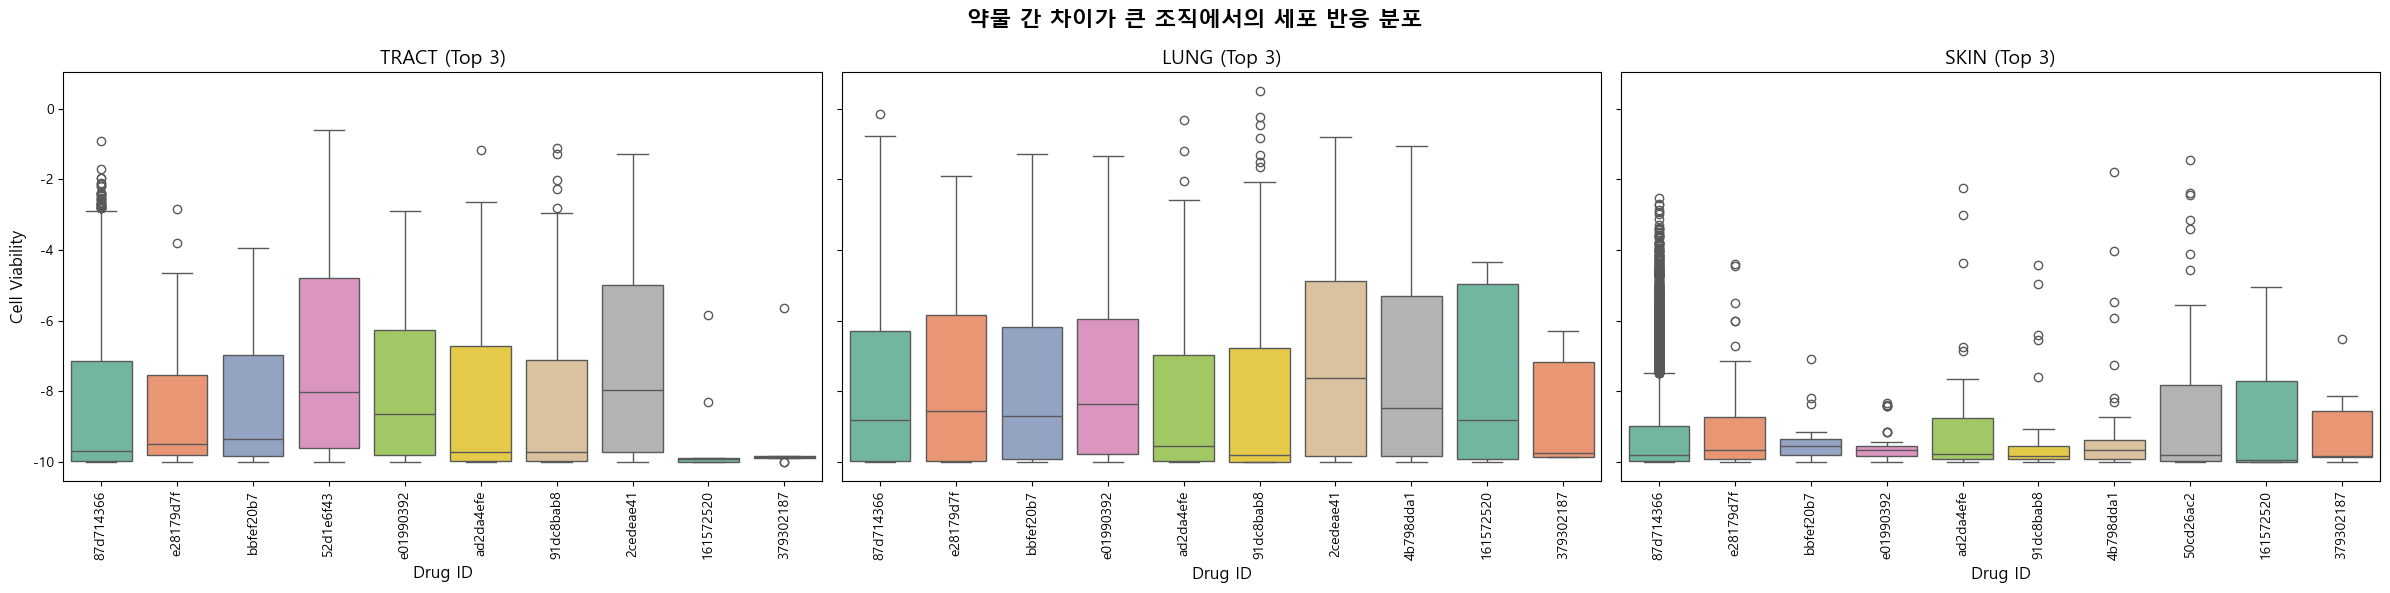

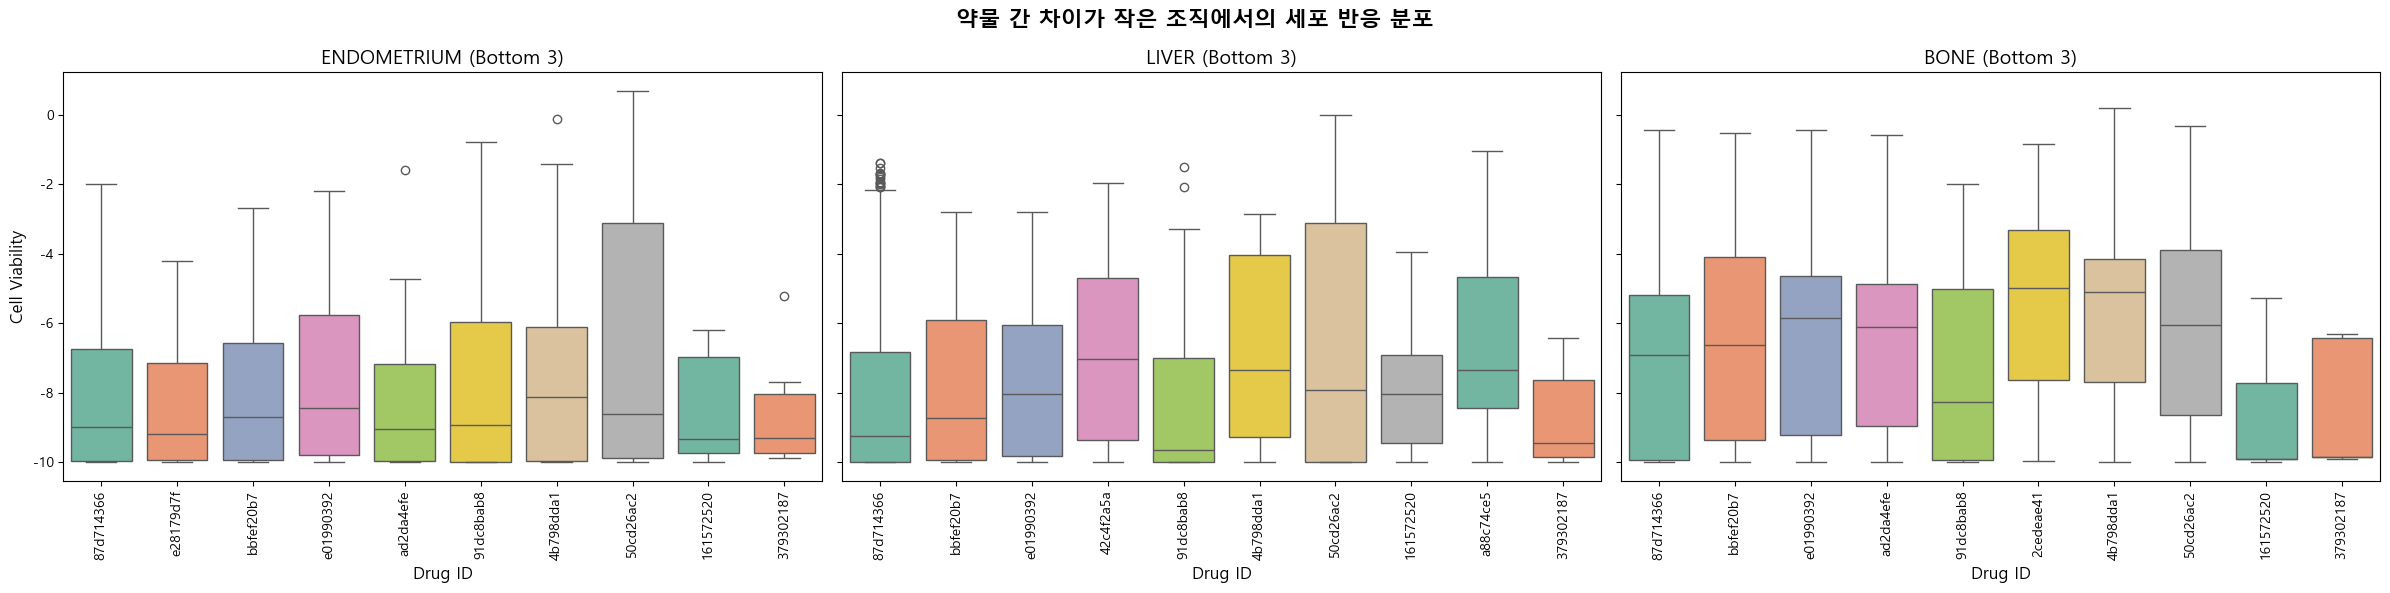

In [70]:
# ANOVA 결과에서 유의미한 상위 조직 3개와 유의미하지 않은 하위 조직 3개 추출
# 약물데이터는 TOP 10으로 필터링
top_tissues = final_anova_df.head(3)['tissue_name'].tolist()
Bottom_tissues = final_anova_df.tail(3)['tissue_name'].tolist()
print(f"약물 간 차이가 가장 큰 조직 (상위 3개): {top_tissues}")
print(f"약물 간 차이가 가장 작은 조직 (하위 3개): {Bottom_tissues}")

# 조직별로 약물 간 차이가 가장 큰 조직 3개 시각화
if top_tissues:
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
    
    for ax, tissue in zip(axes, top_tissues):
        grp = df_cell_response[df_cell_response['tissue'] == tissue]
        top_10_drugs = (
            grp.groupby('drug_id')['cell_viability']
            .median() # 이상치의 영향을 적게 받기 위해, mean이 아닌 median으로 설정.
            .sort_values()
            .head(10)
            .index.tolist()
        )
        plot_df = grp[grp['drug_id'].isin(top_10_drugs)]
        # 시각화(boxplot)
        sns.boxplot(data=plot_df, 
                    x='drug_id', 
                    y='cell_viability', 
                    ax=ax, 
                    palette='Set2'
                    )
        ax.set_title(f"{tissue} (Top 3)", fontsize=14)
        ax.set_xlabel("Drug ID", fontsize=12)
        ax.set_ylabel("Cell Viability", fontsize=12)
        ax.tick_params(axis='x', rotation=90)
    plt.suptitle("약물 간 차이가 큰 조직에서의 세포 반응 분포", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 조직별로 약물 간 차이가 가장 작은 조직 3개 시각화    
if Bottom_tissues:
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
    
    for ax, tissue in zip(axes, Bottom_tissues):
        grp = df_cell_response[df_cell_response['tissue'] == tissue]
        top_10_drugs = (
            grp.groupby('drug_id')['cell_viability']
            .median() # 이상치의 영향을 적게 받기 위해, mean이 아닌 median으로 설정.
            .sort_values()
            .head(10)
            .index.tolist()
        )
        plot_df = grp[grp['drug_id'].isin(top_10_drugs)]
        # 시각화(boxplot)
        sns.boxplot(data=plot_df, 
                    x='drug_id', 
                    y='cell_viability', 
                    ax=ax, 
                    palette='Set2'
                    )
        ax.set_title(f"{tissue} (Bottom 3)", fontsize=14)
        ax.set_xlabel("Drug ID", fontsize=12)
        ax.set_ylabel("Cell Viability", fontsize=12)
        ax.tick_params(axis='x', rotation=90)
    plt.suptitle("약물 간 차이가 작은 조직에서의 세포 반응 분포", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

#### 추가 3. Top 1 약물의 정밀 분석 - Waterfall Plot
- ANOVA p-value 기준으로 가장 조직 특이성이 높은 약물을 선택합니다.
- 세포주별 중앙값 `cell_viability`를 정렬해 waterfall 형태로 시각화합니다.

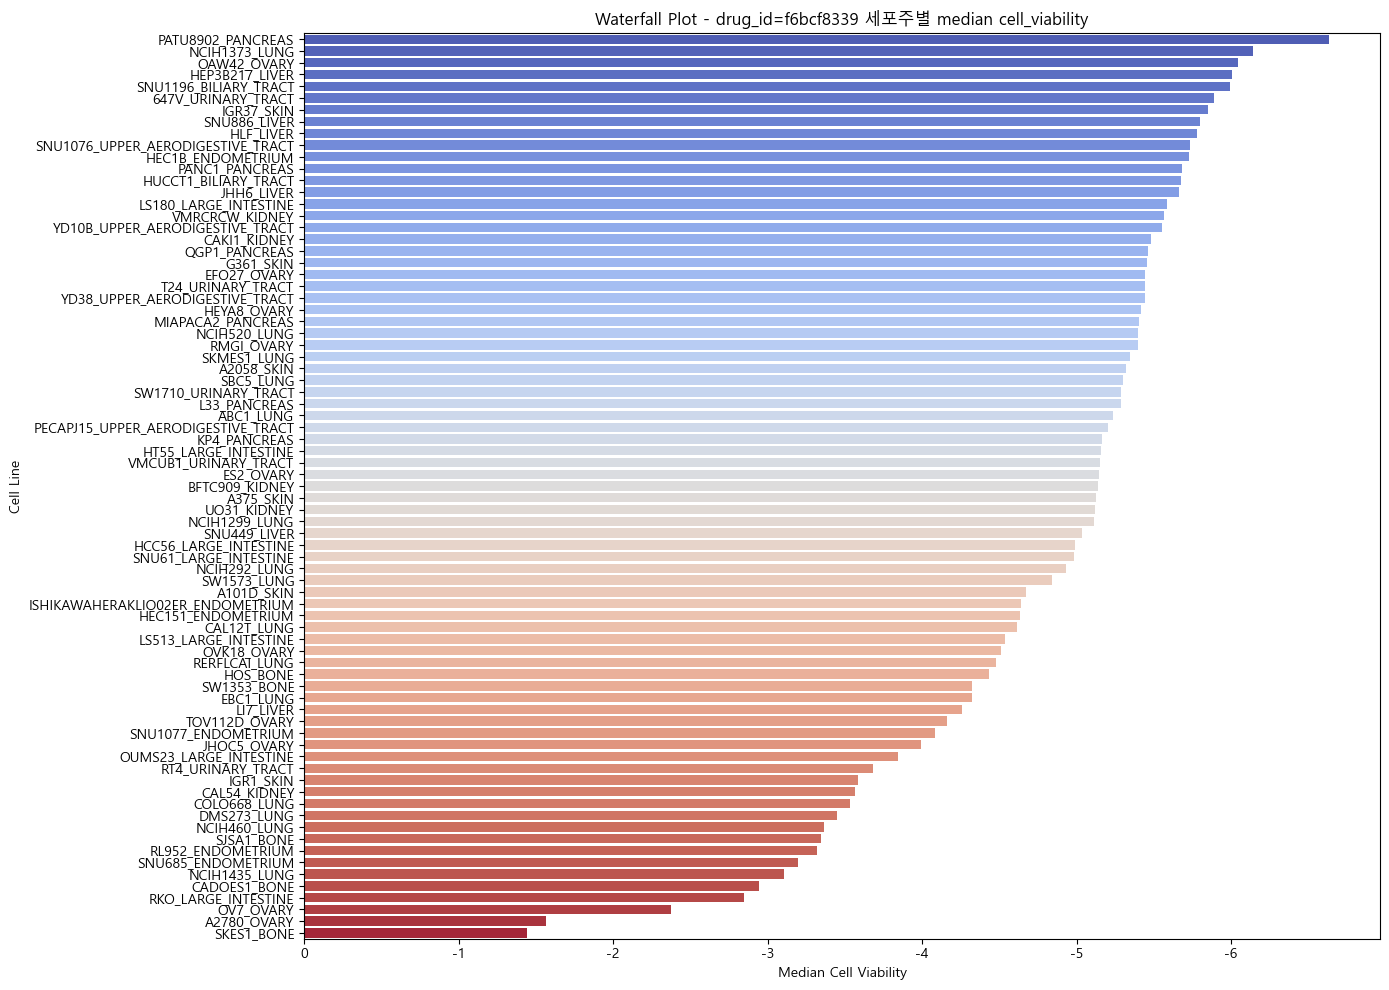

In [71]:
# Top 1 약물 선정 (앞서 분산 기준으로 선정된 top_1_drug 사용)
top_drug = top_1_drug
top_drug_df = df_cell_response[df_cell_response['drug_id'] == top_drug]

# 세포주별 중앙값 계산
cell_line_summary = (
    top_drug_df.groupby('cell_line')['cell_viability']
    .median()
    .sort_values()
    .reset_index()
    .rename(columns={'cell_viability': 'median_viability'})
)

plt.figure(figsize=(14, 10))
sns.barplot(
    data=cell_line_summary,
    x='median_viability',
    y='cell_line',
    palette='coolwarm'
)
plt.title(f'Waterfall Plot - drug_id={top_drug} 세포주별 median cell_viability')
plt.gca().invert_xaxis()
plt.xlabel('Median Cell Viability')
plt.ylabel('Cell Line')
plt.tight_layout()
plt.show()

#### **3. CP(Control Perturbation) vs TR(Treatment) 비교**
    - 대조군이 0이기에, 데이터의 이상치나 노이즈 체크하는 과정을 EDA에 포함하여 분석 신뢰도 높이기 위함
___

In [72]:
# CP vs TR : 대조군이 0임을 활용한 이상치 탐지
c_cols = [col for col in df_train_copy.columns if col.startswith('c-')]
cp_df = df_train_copy[df_train_copy['cp_type'] == 'ctl_vehicle'].copy()
tr_df = df_train_copy[df_train_copy['cp_type'] == 'trt_cp'].copy()

print(f"CP sample 수: {len(cp_df)}, TR sample 수: {len(tr_df)}")
print('CP / TR cp_time 분포:')
display(pd.crosstab(df_train_copy['cp_type'], df_train_copy['cp_time']))


CP sample 수: 1866, TR sample 수: 21948
CP / TR cp_time 분포:


cp_time,24,48,72
cp_type,,,
ctl_vehicle,606,648,612
trt_cp,7166,7602,7180


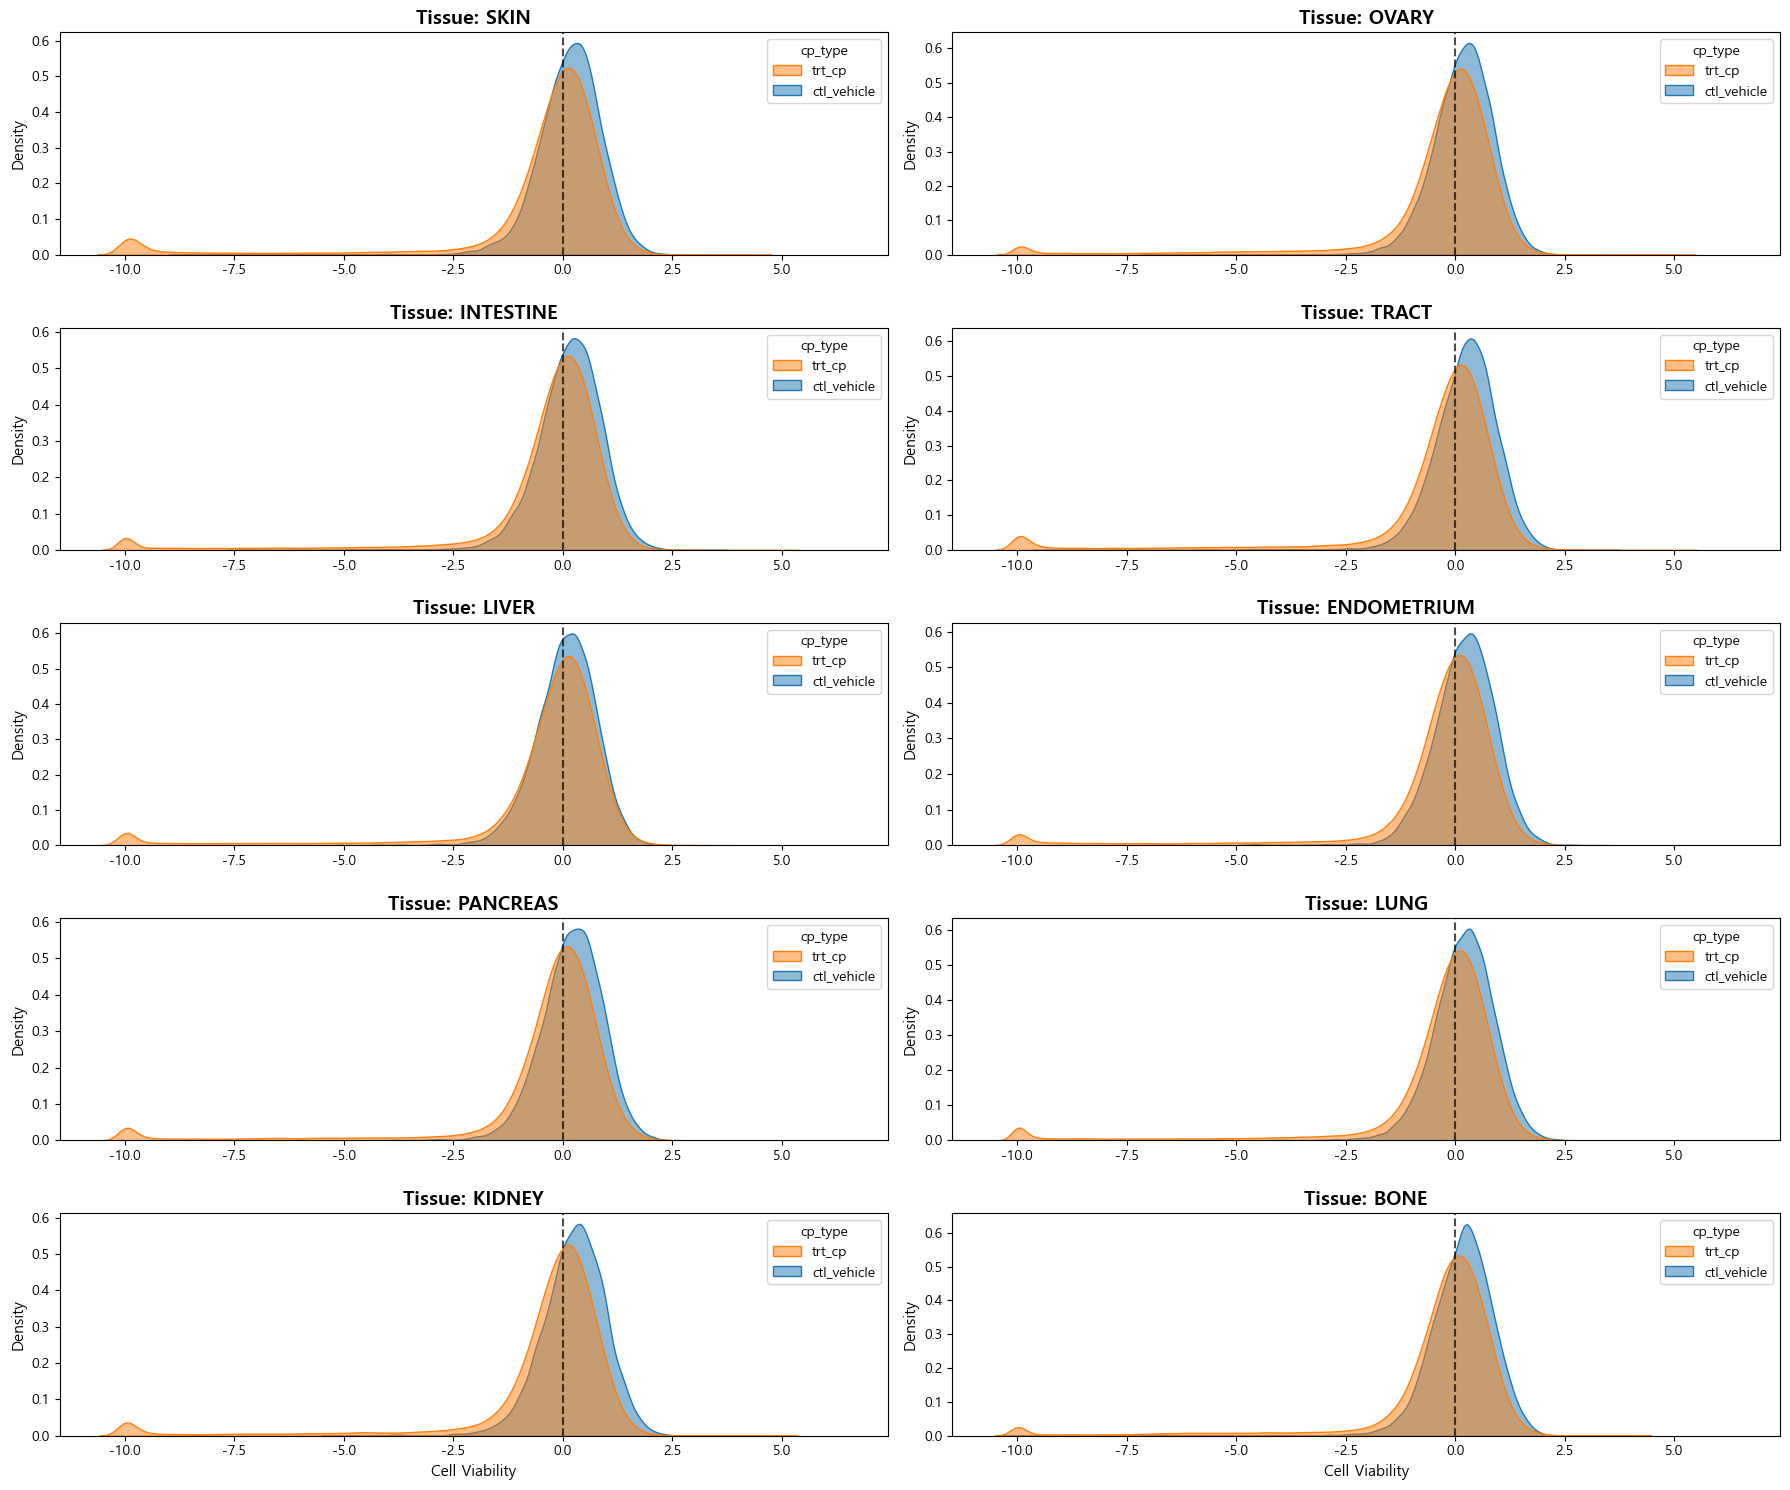

In [ ]:
# 1. 분석할 10개 핵심 조직 리스트
target_tissues = ['SKIN', 'OVARY', 'INTESTINE', 'TRACT', 'LIVER', 'ENDOMETRIUM', 'PANCREAS', 'LUNG', 'KIDNEY', 'BONE']

# 해당 조직의 데이터만 필터링
df_target = df_cell_response[df_cell_response['tissue'].isin(target_tissues)].copy()

# 2. 3x3 그리드 설정 (그래프 크기 조정)
fig, axes = plt.subplots(5, 2, figsize=(18, 15), sharex=True) # x축 스케일 통일 유지
axes = axes.flatten()

# 3. 조직별로 반복하며 그래프 그리기
for i, tissue in enumerate(target_tissues):
    subset = df_target[df_target['tissue'] == tissue]
    
    # KDE(밀도) 플롯 그리기
    sns.kdeplot(data=subset, x='cell_viability', hue='cp_type', fill=True, 
                common_norm=False, ax=axes[i], alpha=0.5, palette={'ctl_vehicle':'#1f77b4', 'trt_cp':'#ff7f0e'})
    
    axes[i].set_title(f"Tissue: {tissue}", fontsize=14, fontweight='bold')
    axes[i].axvline(0, color='k', linestyle='--', alpha=0.7) # 기준선 0
    
    # [핵심 수정 부분] 가려진 x축 정보 강제 호출
    axes[i].set_xlabel('Cell Viability', fontsize=11)
    axes[i].set_ylabel('Density', fontsize=11)
    axes[i].tick_params(labelbottom=True) # 숨겨진 x축 눈금(숫자)을 모든 그래프에 켜기!

# 위아래 그래프 간에 라벨이 겹치지 않도록 세로 여백(h_pad)을 넉넉히 줍니다.
plt.tight_layout(h_pad=2.0) 
plt.show()

In [75]:
# 3. 조직별 CP vs TR 겹침 정도 분석 (Mann-Whitney U test + Cohen's d)
overlap_results = []

for tissue in target_tissues:
    # 조직별 CP와 TR 데이터 분리
    cp_data = df_target[(df_target['tissue'] == tissue) & (df_target['cp_type'] == 'ctl_vehicle')]['cell_viability']
    tr_data = df_target[(df_target['tissue'] == tissue) & (df_target['cp_type'] == 'trt_cp')]['cell_viability']
    
    # 1. 유의성 검정 (Mann-Whitney U test)
    # 두 분포가 통계적으로 유의미하게 다른가?
    stat, p_val = mannwhitneyu(cp_data, tr_data, alternative='two-sided')
    
    # 2. 겹침 정도 / 효과 크기 (Cohen's d) 계산
    # 두 집단의 평균 차이를 통합 표준편차로 나눈 값 (분포가 덜 겹칠수록 커짐)
    n1, n2 = len(cp_data), len(tr_data)
    var_cp, var_tr = np.var(cp_data, ddof=1), np.var(tr_data, ddof=1)
    
    # 통합 표준편차 (Pooled Standard Deviation)
    pooled_std = np.sqrt(((n1 - 1) * var_cp + (n2 - 1) * var_tr) / (n1 + n2 - 2))
    
    # Cohen's d (양수로 만들기 위해 대조군 평균 - 실험군 평균)
    # 대조군(0 부근)이 실험군(마이너스)보다 크므로 양수가 나옴
    cohens_d = (np.mean(cp_data) - np.mean(tr_data)) / pooled_std
    # 크기에 따른 해석
    if cohens_d < 0.2:
        effect_size_interp = "무시할 만한 수준 (Negligible)"
    elif cohens_d < 0.5:
        effect_size_interp = "작은 효과 (Small)"
    elif cohens_d < 0.8:
        effect_size_interp = "중간 효과 (Medium)"
    else:
        effect_size_interp = "큰 효과 (Large)"
    
    overlap_results.append({
        'Tissue': tissue,
        'Cohen_d (차이 크기)': cohens_d,
        '효과 크기 해석': effect_size_interp,
        'p-value (유의성)': p_val,
        '대조군 데이터 수': n1,
        '실험군 데이터 수': n2
    })

# 결과를 데이터프레임으로 만들고, 차이가 가장 큰(Cohen's d가 높은) 순서대로 정렬
df_overlap = pd.DataFrame(overlap_results).sort_values('Cohen_d (차이 크기)', ascending=False).reset_index(drop=True)

print("=== 조직별 약물 처리 효과 크기 및 유의성 검정 결과 ===")
display(df_overlap)

=== 조직별 약물 처리 효과 크기 및 유의성 검정 결과 ===


,Tissue,Cohen_d (차이 크기),효과 크기 해석,p-value (유의성),대조군 데이터 수,실험군 데이터 수
0,KIDNEY,0.383047,작은 효과 (Small),0.000000e+00,9330,109740
1,TRACT,0.377255,작은 효과 (Small),0.000000e+00,20526,241428
2,ENDOMETRIUM,0.354297,작은 효과 (Small),0.000000e+00,11196,131688
3,PANCREAS,0.351426,작은 효과 (Small),0.000000e+00,11196,131688
4,SKIN,0.345423,작은 효과 (Small),1.387076e-277,11196,131688
5,LUNG,0.343567,작은 효과 (Small),0.000000e+00,27990,329220
6,OVARY,0.337707,작은 효과 (Small),0.000000e+00,18660,219480
7,BONE,0.331245,작은 효과 (Small),2.593859e-237,9330,109740
8,INTESTINE,0.330708,작은 효과 (Small),7.959123e-301,13062,153636
9,LIVER,0.283243,작은 효과 (Small),2.664784e-104,11196,131688


#### **４.약물 노출시간에 따른 약효 효과 확인 > lineplot**
___

In [76]:
def calculate_z_factor(df, label_col, positive_label, negative_label):
  
    pos = df[df[label_col] == positive_label]
    neg = df[df[label_col] == negative_label]
    
    z_factors = {}

    for col in df.select_dtypes(include='number').columns:  # 숫자형만
        
        mu_p = pos[col].mean()
        mu_n = neg[col].mean()
        sigma_p = pos[col].std()
        sigma_n = neg[col].std()
        
        denom = abs(mu_p - mu_n)
        if denom == 0:
            z_factors[col] = float('nan')
            continue
        
        z = 1 - (3 * (sigma_p + sigma_n) / denom)
        z_factors[col] = z
    
    return pd.Series(z_factors)
# CP vs TR 데이터로 z-factor 계산 결과
z_scores = calculate_z_factor(
    df=train_master,
    label_col='cp_type',
    positive_label='trt_cp',
    negative_label='ctl_vehicle'
)
print(z_scores)

cp_time                                 -1880.573795
g-0                                       -17.129410
g-1                                       -24.344948
g-2                                       -28.890331
g-3                                      -612.136394
                                            ...     
ubiquitin_specific_protease_inhibitor    -180.423537
vegfr_inhibitor                           -32.955934
vitamin_b                                 -86.113319
vitamin_d_receptor_agonist                -70.106634
wnt_inhibitor                             -80.090688
Length: 1079, dtype: float64


전체 피처 수: 872
grade
poor    872
Name: count, dtype: int64

[상위 20개 피처 (Z-factor 높은 순)]
         z_factor grade
feature                
g-764   -6.573421  poor
g-365   -6.850044  poor
g-445   -7.112812  poor
c-73    -7.135135  poor
g-39    -7.152936  poor
g-100   -7.190846  poor
g-367   -7.224174  poor
g-68    -7.333735  poor
g-312   -7.428789  poor
c-13    -7.472863  poor
g-620   -7.812530  poor
g-138   -7.896417  poor
g-58    -7.951151  poor
g-229   -7.963580  poor
g-50    -8.011257  poor
g-223   -8.133072  poor
g-424   -8.159470  poor
c-98    -8.164079  poor
g-578   -8.172651  poor
g-374   -8.204419  poor


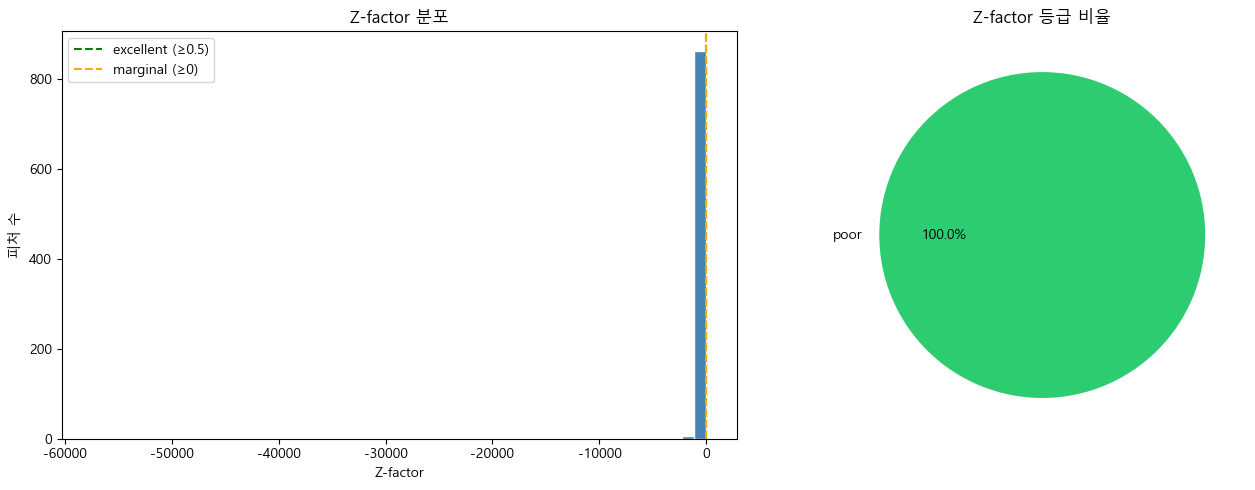


Hit 피처 (Z' ≥ 0.5): 0개
Empty DataFrame
Columns: [z_factor, grade]
Index: []


In [77]:
# ============================================================
# Z-factor 계산
# ============================================================

def calculate_z_factor(df, label_col, positive_label, negative_label, feature_cols=None):
    """
    Z' = 1 - 3*(σ_pos + σ_neg) / |μ_pos - μ_neg|
    
    Z' >= 0.5 : 우수 (excellent)
    0 <= Z' < 0.5 : 경계 (marginal)
    Z' < 0  : 분리 불가 (poor)
    """
    pos = df[df[label_col] == positive_label]
    neg = df[df[label_col] == negative_label]

    if feature_cols is None:
        feature_cols = df.select_dtypes(include='number').columns.tolist()

    results = []
    for col in feature_cols:
        mu_p, mu_n = pos[col].mean(), neg[col].mean()
        sig_p, sig_n = pos[col].std(), neg[col].std()
        denom = abs(mu_p - mu_n)

        z = 1 - (3 * (sig_p + sig_n) / denom) if denom != 0 else float('nan')

        results.append({
            'feature': col,
            'z_factor': z,
            'mu_pos': mu_p,
            'mu_neg': mu_n,
            'std_pos': sig_p,
            'std_neg': sig_n,
        })

    result_df = pd.DataFrame(results).set_index('feature')
    return result_df


# ── 피처 컬럼 지정 (g-, c- 만) ──────────────────────────────
feature_cols = [c for c in train_features.columns if c.startswith('g-') or c.startswith('c-')]

z_result = calculate_z_factor(
    df=train_features,
    label_col='cp_type',
    positive_label='trt_cp',
    negative_label='ctl_vehicle',
    feature_cols=feature_cols
)

# ── 등급 분류 ────────────────────────────────────────────────
def classify_z(z):
    if z >= 0.5:  return 'excellent'
    elif z >= 0:  return 'marginal'
    else:         return 'poor'

z_result['grade'] = z_result['z_factor'].apply(classify_z)

# ── 결과 요약 ────────────────────────────────────────────────
print('=' * 50)
print(f"전체 피처 수: {len(z_result)}")
print(z_result['grade'].value_counts())
print('=' * 50)
print("\n[상위 20개 피처 (Z-factor 높은 순)]")
print(z_result.sort_values('z_factor', ascending=False).head(20)[['z_factor', 'grade']])

# ── 시각화 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 분포 히스토그램
axes[0].hist(z_result['z_factor'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='green',  linestyle='--', label='excellent (≥0.5)')
axes[0].axvline(0.0, color='orange', linestyle='--', label='marginal (≥0)')
axes[0].set_title('Z-factor 분포')
axes[0].set_xlabel('Z-factor')
axes[0].set_ylabel('피처 수')
axes[0].legend()

# 등급별 비율 파이차트
grade_counts = z_result['grade'].value_counts()
axes[1].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Z-factor 등급 비율')

plt.tight_layout()
plt.show()

# ── Hit 피처 추출 ─────────────────────────────────────────
hits = z_result[z_result['z_factor'] >= 0.5].sort_values('z_factor', ascending=False)
print(f"\nHit 피처 (Z' ≥ 0.5): {len(hits)}개")
print(hits[['z_factor', 'grade']])


전체 약물 중 Hit 기준(생존율 -2.0 이하)을 통과한 타겟 약물 수: 1844개


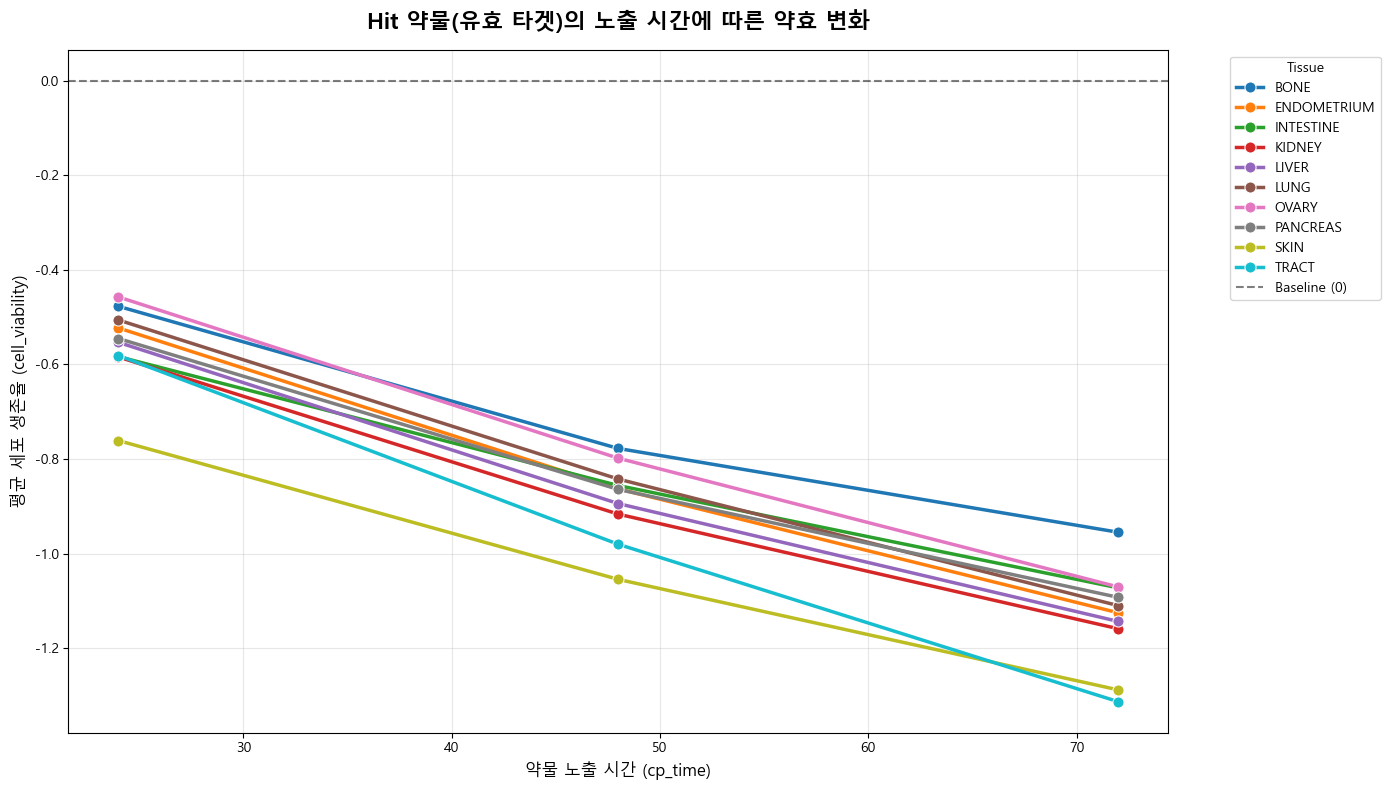

In [78]:
# 약물 노출시간에 따른 약효 효과 확인 (Lineplot)
 # tissue별로 나눠, cp_time이 24, 48, 72인 경우에 대해서 각각의 cell_viability 평균값을 계산하여 시각화

# 1. 'Hit 약물' 기준 설정 및 필터링 
 # HIT 약물: 스크리닝 실험을 통해 유효성이 확인된 초기 화합물 (예: 한 번이라도 생존율 -2.0 이하를 기록한 약물)
hit_threshold = -2.0
hit_drugs = df_cell_response[
    (df_cell_response['cp_type'] == 'trt_cp') & 
    (df_cell_response['cell_viability'] <= hit_threshold)
]['drug_id'].unique()

print(f"전체 약물 중 Hit 기준(생존율 {hit_threshold} 이하)을 통과한 타겟 약물 수: {len(hit_drugs)}개")

# 2. Hit 약물들만의 데이터로 필터링
df_hit_time = df_cell_response[
    (df_cell_response['cp_type'] == 'trt_cp') & 
    (df_cell_response['drug_id'].isin(hit_drugs))
].copy()

# 3. Hit 약물들의 조직별/시간별 평균 계산
time_summary_hit = (
    df_hit_time.groupby(['tissue', 'cp_time'])['cell_viability']
    .mean()
    .reset_index()
)

# 4. 시각화 (Lineplot)
plt.figure(figsize=(14, 8))
sns.lineplot(data=time_summary_hit, x='cp_time', y='cell_viability', hue='tissue', marker='o', linewidth=2.5, markersize=8)

plt.title("Hit 약물(유효 타겟)의 노출 시간에 따른 약효 변화", fontsize=16, fontweight='bold', pad=15)
plt.xlabel('약물 노출 시간 (cp_time)', fontsize=12)
plt.ylabel('평균 세포 생존율 (cell_viability)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Baseline (0)')
plt.legend(title='Tissue', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **조직별 Hit 약물 분포 분석 (Bar Chart)**

=== 조직별 Hit 약물 분포 (생존율 -2.0 이하) ===


,조직 (Tissue),Hit 약물 수 (개),Top 3 맹독성 약물 ID
0,LUNG,942,"100370c58, 10afa009a, fcfed83c3"
1,OVARY,797,"01af4c881, 9679541e9, 8dad6ac60"
2,TRACT,783,"00d2de1d8, 01af4c881, bcfa1dcb0"
3,SKIN,725,"100370c58, eb1e0300a, 74fed7806"
4,LIVER,696,"f985fee46, b016fdb77, 12d8dfdbb"
5,INTESTINE,679,"858545f06, 161572520, 74fed7806"
6,BONE,639,"0ebfd755d, fc9c586b9, f5dcd0b85"
7,ENDOMETRIUM,632,"01af4c881, ec05ebd4d, eb1e0300a"
8,PANCREAS,629,"01af4c881, e9b5faf16, eb1e0300a"
9,KIDNEY,595,"a90ee8ca7, 1ac3046e2, 74fed7806"


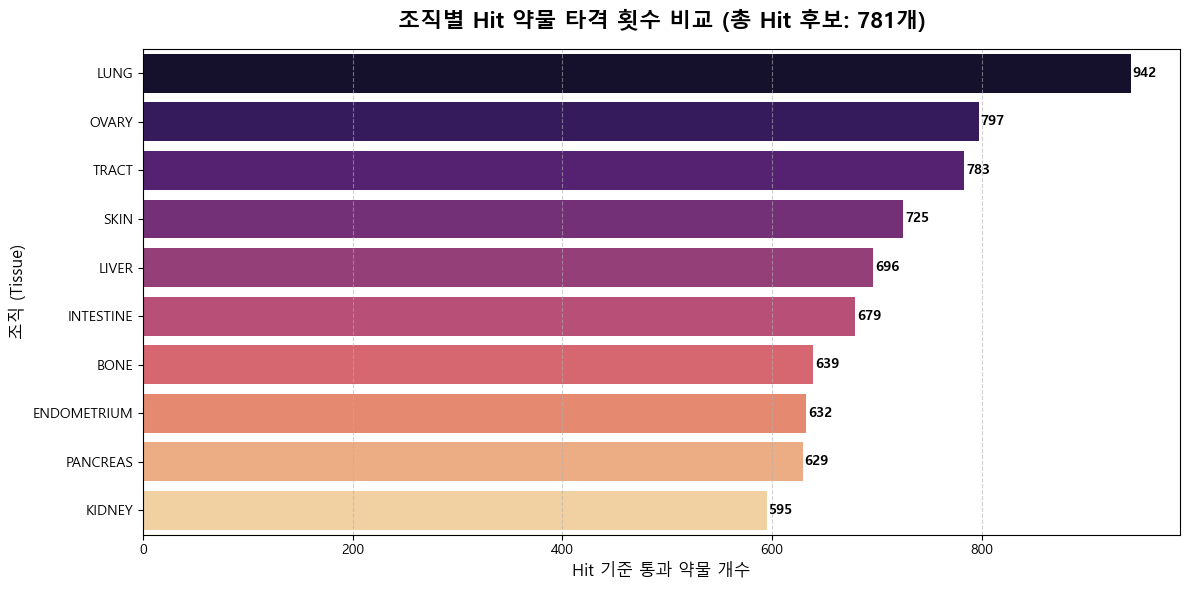

In [80]:
# 조직별 Hit 약물 분포 분석 (Bar Chart)

# 1. 10개 타겟 조직 데이터 및 Hit 기준 설정
target_tissues = ['SKIN', 'OVARY', 'INTESTINE', 'TRACT', 'LIVER', 'ENDOMETRIUM', 'PANCREAS', 'LUNG', 'KIDNEY', 'BONE']
hit_threshold = -2.0

# 2. 실험군(trt_cp) 중 타겟 조직이면서 Hit 기준(-2.0 이하)을 만족하는 데이터만 필터링
hit_data = df_cell_response[
    (df_cell_response['cp_type'] == 'trt_cp') & 
    (df_cell_response['tissue'].isin(target_tissues)) & 
    (df_cell_response['cell_viability'] <= hit_threshold)
].copy()

# 3. 조직별 Hit 약물 개수 및 Top 3 약물 추출
hit_summary = []

for tissue, group in hit_data.groupby('tissue'):
    # 해당 조직에서 Hit 기준을 통과한 고유 약물 개수
    n_hits = group['drug_id'].nunique()
    
    # 해당 조직에서 생존율을 가장 많이 떨어뜨린(최소값) 순서대로 정렬하여 Top 3 약물 추출
    top_drugs = group.groupby('drug_id')['cell_viability'].min().sort_values().head(3).index.tolist()
    
    hit_summary.append({
        '조직 (Tissue)': tissue,
        'Hit 약물 수 (개)': n_hits,
        'Top 3 맹독성 약물 ID': ", ".join(top_drugs)
    })

df_hit_summary = pd.DataFrame(hit_summary).sort_values('Hit 약물 수 (개)', ascending=False).reset_index(drop=True)

print(f"=== 조직별 Hit 약물 분포 (생존율 {hit_threshold} 이하) ===")
display(df_hit_summary)

# 4. 시각화 (가로 바 차트)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_hit_summary, x='Hit 약물 수 (개)', y='조직 (Tissue)', palette='magma')

plt.title(f"조직별 Hit 약물 타격 횟수 비교 (총 Hit 후보: 781개)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Hit 기준 통과 약물 개수", fontsize=12)
plt.ylabel("조직 (Tissue)", fontsize=12)

# 바 끝에 숫자 달아주기
for index, value in enumerate(df_hit_summary['Hit 약물 수 (개)']):
    plt.text(value + 2, index, str(value), color='black', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **조직별로 Hit 약물 수가 TOP(많은) 3와 BOTTOM(적은) 3개 조직 선정 -> 약물의 효능 차이 분석**


▶ 분석 진행 중: LUNG (Hit 약물 수: 942개)


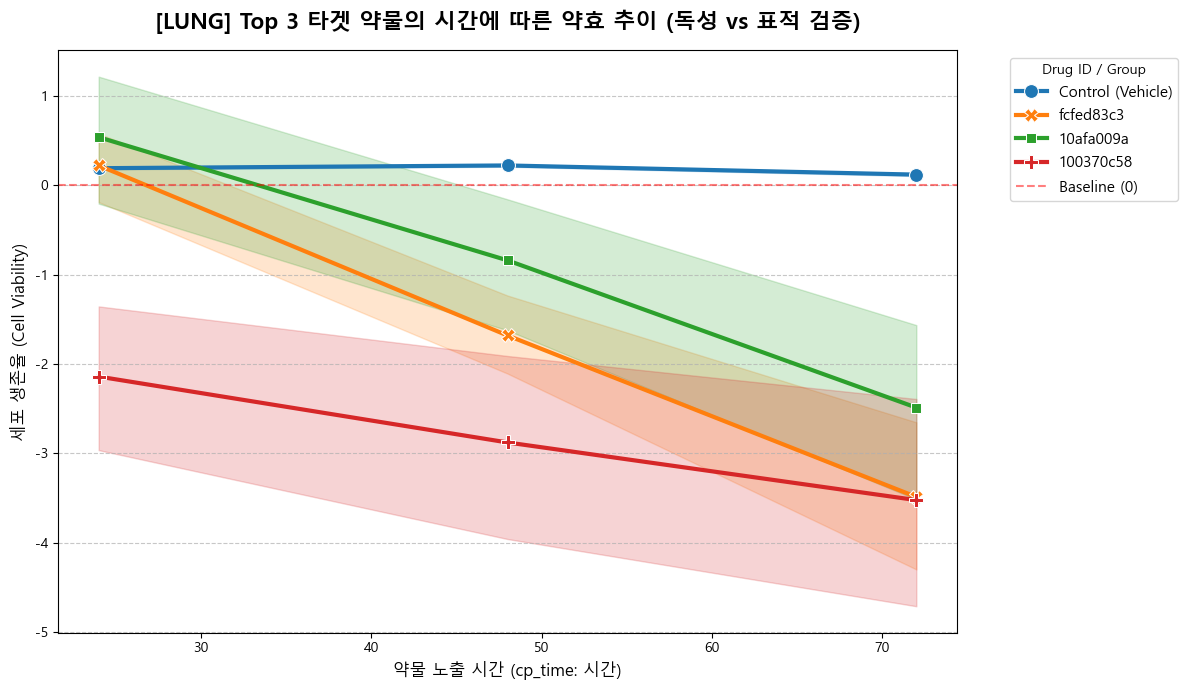


▶ 분석 진행 중: OVARY (Hit 약물 수: 797개)


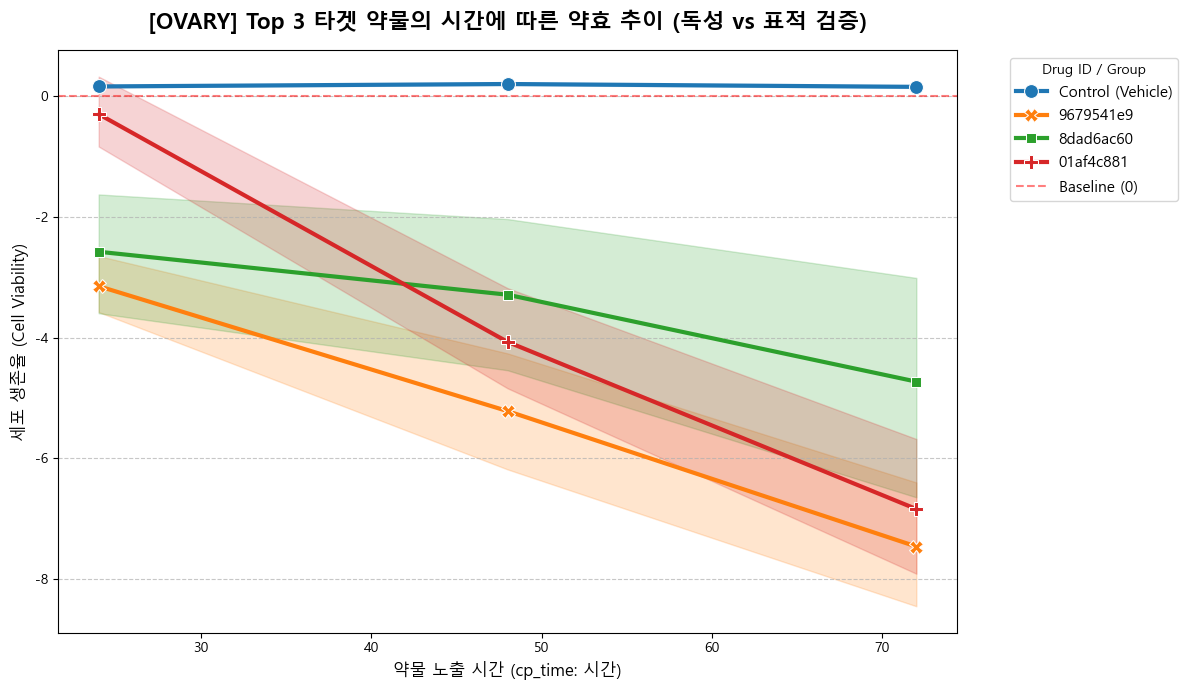


▶ 분석 진행 중: TRACT (Hit 약물 수: 783개)


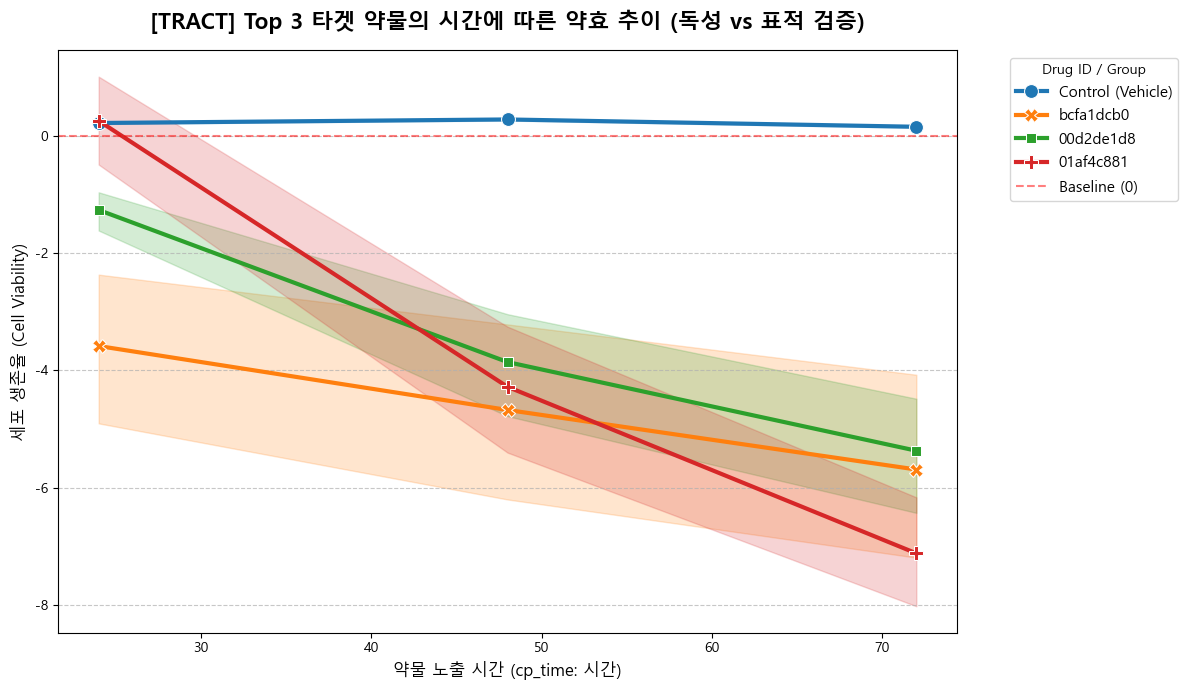


▶ 분석 진행 중: ENDOMETRIUM (Hit 약물 수: 632개)


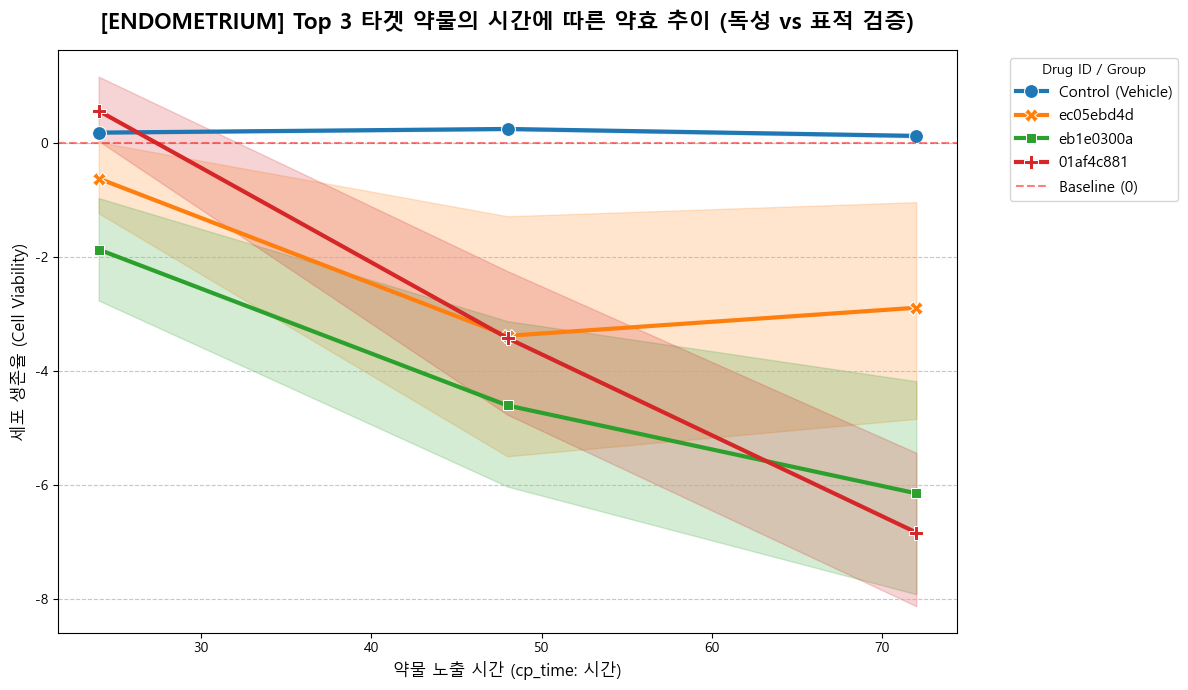


▶ 분석 진행 중: PANCREAS (Hit 약물 수: 629개)


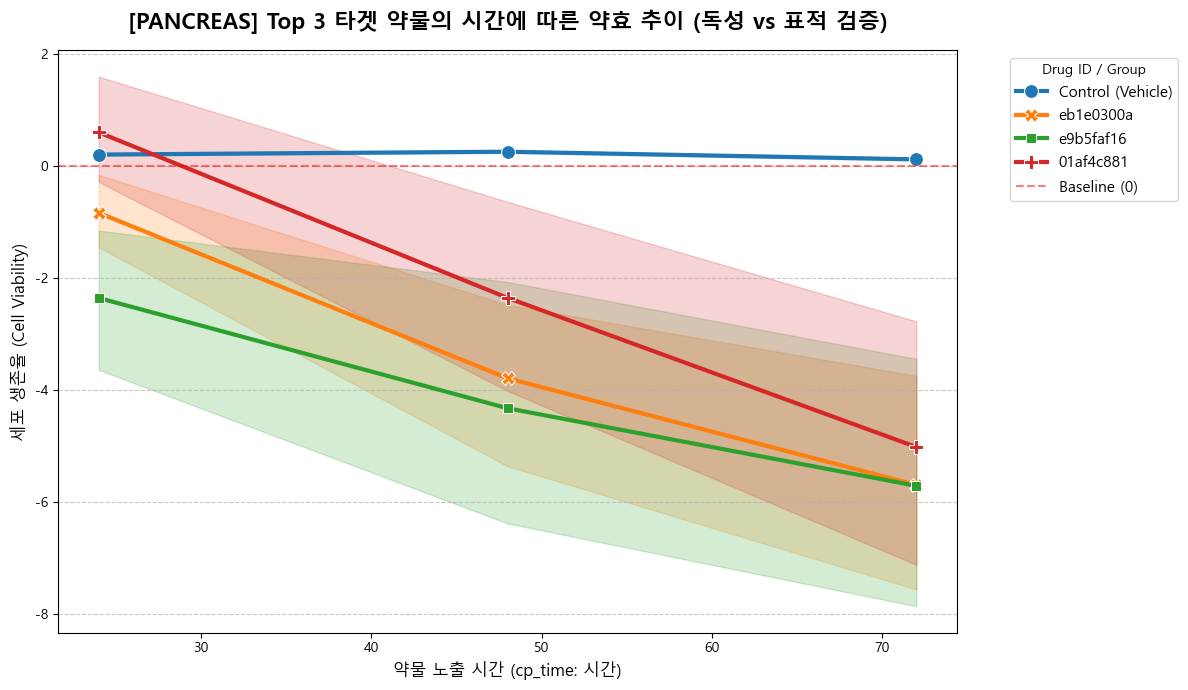


▶ 분석 진행 중: KIDNEY (Hit 약물 수: 595개)


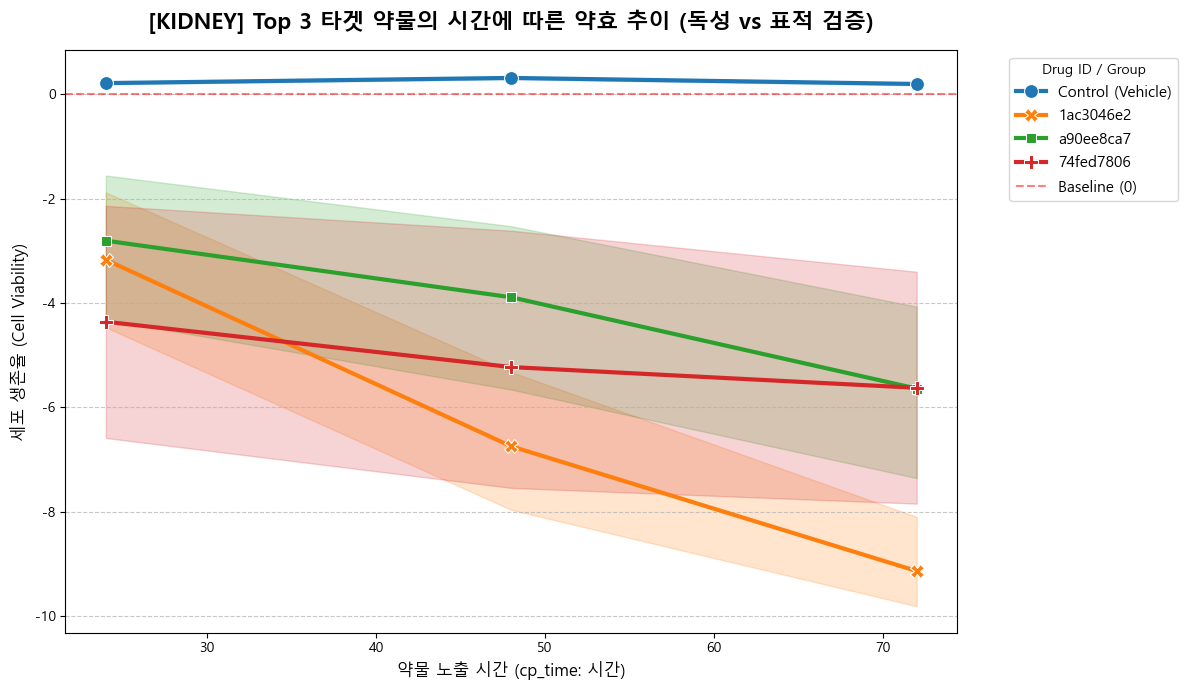

In [82]:
# 조직별 Hit 약물 조직 TOP3 / Bottom 3 선정
top_3_tissues = df_hit_summary.head(3)
bottom_3_tissues = df_hit_summary.tail(3)

# 데이터 하나로 합치기
extreme_tissues_df = pd.concat([top_3_tissues, bottom_3_tissues])

# 그래프로 시각화
def plot_time_course_top_drugs_upgraded(df, tissue_name, top_drugs_list):
    # 1. 해당 조직의 Top 3 약물 데이터 + 대조군(ctl_vehicle) 데이터 동시 추출
    plot_df = df[
        (df['tissue'] == tissue_name) & 
        ((df['drug_id'].isin(top_drugs_list)) | (df['cp_type'] == 'ctl_vehicle'))
    ].copy()
    
    # 그래프 범례를 예쁘게 표시하기 위해 대조군의 drug_id 이름을 알기 쉽게 변경
    plot_df.loc[plot_df['cp_type'] == 'ctl_vehicle', 'drug_id'] = 'Control (Vehicle)'
    
    # 2. 시각화 (Lineplot)
    plt.figure(figsize=(12, 7))
    
    # errorbar='ci' (기본값): 동일 약물/시간에 여러 용량(dose)이 섞여 있을 경우 신뢰구간(그림자)으로 오차 표시
    sns.lineplot(data=plot_df, x='cp_time', y='cell_viability', hue='drug_id', 
                 style='drug_id', markers=True, dashes=False, linewidth=3, markersize=10)
    
    plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Baseline (0)')
    
    # 3. 디자인 디테일 
    plt.title(f"[{tissue_name}] Top 3 타겟 약물의 시간에 따른 약효 추이 (독성 vs 표적 검증)", fontsize=16, fontweight='bold', pad=15)
    plt.ylabel("세포 생존율 (Cell Viability)", fontsize=12)
    plt.xlabel("약물 노출 시간 (cp_time: 시간)", fontsize=12)
    
    # 범례 위치 조정 (그래프 밖으로 빼기)
    plt.legend(title="Drug ID / Group", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 그래프 반복문으로 그리기
for index, row in extreme_tissues_df.iterrows():
    tissue = row['조직 (Tissue)']
    hit_count = row['Hit 약물 수 (개)']
    
    # 텍스트로 묶여있던 약물 ID들을 다시 리스트로 분리
    top_3_drugs = [drug.strip() for drug in row['Top 3 맹독성 약물 ID'].split(",")]
    
    print(f"\n▶ 분석 진행 중: {tissue} (Hit 약물 수: {hit_count}개)")
    
    # 앞서 만든 시각화 함수 호출
    plot_time_course_top_drugs_upgraded(df_cell_response, tissue, top_3_drugs)